# Session 3: Fitting functions (1D) and spectroscopy

Script author: g.savini@ucl.ac.uk <br>
Updated: 28/01/2026<br>

Task completed by: Klara Kurucova | 29/01/2026 | PHAS0020

<div class="alert alert-success"> 
    
**Task 3: From fitting pre-determined functions (pdfs, lines, polynomials, ...) to fitting generic, own-defined functions. A working example: Stellar spectroscopy.**

This task is split in 3 parts:
<ul>
<li> Part A: 
<ol>
    <li> Read through the notebook guidelines before starting your work, then [1] write a one paragraph abstract on what your aim is in this Task.
    <li> [2] Load a data file taken with the Avantes Czerny-Turner spectrometer on the C14 from a text file and store the header in a string array.
    <li> [3] Use the fitting tools we are familiar from last year with (2nd deg. polynomial) to identify the peak position of a line (the Balmer $H_{\delta}$)</ol>
<li> Part B: 
<ol>     
    <li> [4] Define the specific function that we plan to make use of (see line profile section below)
    <li> [5] Normalize the data by dividing the spectrum by the a polynomial fit of the continuum emission of the star to facilitate the following feature-specific fits of a subset. 
    <li> [6] Follow example to use the user-defined function to do own fit.
    <li> [7] Comment on results
    </ol>
        
<li> Part C: [8] Use what you've learned on statistics  (including in Task 1 - Week 1) to look at the residuals of the fit performed in Part 1. Explore again the meaning of reduced $\chi^2$ and explore the goodness fit as a function of parameters used. </li>

</ul>

</div>



<div class="alert alert-success"> 
    
**Intended learning outcomes:**

By the end of this session, you should be able to:
<ul>
<li> Use Python to fit a set of data to a polynomial and other functions; </li>
<li> To evaluate the goodness of fit using $\chi^2$; </li> 
<li> Understanding the use of the matrix of covariance; </li>
<li> Understand how the process is expedited with in-built python tools</li>
</ul>

</div>

## Introduction 

In this task we will examine the spectrum of Vega. We will investigate the $H_\delta$ and $H_\gamma$ lines through various methods. We will look at different methods of fitting data points of each spectral line including a quadratic fit, fit of the continuum and a Lorentzian fit. We will compare the results for the spectral wavelength from these different means of measurement and evaluate our final fits using statistical methods such as the plot of normalised residuals and $\chi^2$ reduced.

The final aim of this Jupyter Notebook will be to compute the speed due to doppler effect for each of the spectral lines. Comparing our results, we will be able to infer the goodness of our fits and their reliability.

## Fitting with standard functions: polynomials.

<div class='alert alert-success'> 
    In physics and astronomy we often meet an experimental relation between observables which has no predefined mathematical relation. This may either be because the theoretical equation which describes the observed behaviour is difficult to solve, or because the situation is complicated by several factors. However, we can still measure the dependence between the variables experimentally and compare a range of dependencies in order to make predictions on future observations.

In this kind of situation it is convenient to fit an equation to our experimental data. We can then use the fitted equation to interpolate, i.e. to calculate the expected value of a variable between our measured data points, and to extrapolate, i.e. to calculate the expected value beyond the range of our measured data points. This procedure is often called “parameterizing” the relationship.

In principle we could use any form of equation to fit a set of measured data, but if we have no theoretical basis for fitting a particular type of curve it is often simplest and easiest to fit a power law (mathematically a polynomial). The order of the polynomial and the coefficients of each term in the fitted equation are called the “parameters” of our fit.

You should have seen last year how <tt> np.polyfit </tt> is used to do so, but we will practice it again here to begin with to refresh our knowledge (and to see how this can be useful anyway and a fast way to assess parameters to first order).

Once we do this we'll move on to generic fitting.</div>

<div class='alert alert-success'>    
<b> Part A1: Load the dataset with headers </b><br>
The first thing we need to do is import the usual modules we'll need. As there are a few extras, this is done for you.
</div>    

In [8]:
#import relevant libraries

import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as stats
from scipy import optimize

%matplotlib inline

In [10]:
# i filter warnings as using LaTeX notation in matplolib graphs raised warnings and it just made things look messy
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

<div class='alert alert-success'> 
The datafile this week has a header which provides information on the data file structure and content.<br>
So:
<ul>
    <li> Load the data as you have done last week, after checking (with a text editor) how many rows to skip and the type of delimiter.</li>
    <li> To load the entire set of header lines in an array of strings, use the same numpy command but with <tt> dtype='str' </tt>, identifying how many rows with the keyword <tt>maxrows=</tt> and <tt> delimiter='None'</tt> the data as you have done last week, after checking how many rows to skip and the type of delimiter.</li></ul>
    <li> Finally limit the data only to the first 2000 elements of each column.</li>
</div>



If we open the data set in a separate window, we can see that the header is loaded in a strange way as the header and the data headings are mismatched and hence will not load uniformly. For that reason we just load the header. The data is comprised of 5 data columns containing data as follows: wavenumber, sample, dark, reference and scope corrected for dark. We will work with the first two columns but still load all the columns just in case we need them.

In [14]:
### STUDENT GENERATED CELL ###

#load the data 
data = np.loadtxt('vega_1s_10av_2111292U1_vega_10av_1s_2.txt',delimiter=';',skiprows=8, max_rows = 2000)
print(data)

#load the header 
header = np.loadtxt('vega_1s_10av_2111292U1_vega_10av_1s_2.txt', dtype=str, delimiter=None, skiprows=1, max_rows=4, usecols=(0,1,2,3))
print(header)

[[ 1.1093290e+04  4.2631800e+02  4.1897500e+02  0.0000000e+00
   7.3425000e+00]
 [ 1.1096260e+04  4.6531800e+02  4.2597500e+02  0.0000000e+00
   3.9342500e+01]
 [ 1.1099220e+04  4.1201700e+02  4.1297500e+02  0.0000000e+00
  -9.5752000e-01]
 ...
 [ 2.7510640e+04  6.2133500e+02  3.6196800e+02  0.0000000e+00
   2.5936740e+02]
 [ 2.7532840e+04  5.8539000e+02  3.6296700e+02  0.0000000e+00
   2.2242212e+02]
 [ 2.7555070e+04  5.3782400e+02  3.0397100e+02  0.0000000e+00
   2.3385205e+02]]
[['Integration' 'time' '[ms]:' '1000.000']
 ['Averaging' 'Nr.' '[scans]:' '10']
 ['Smoothing' 'Nr.' '[pixels]:' '0']
 ['Data' 'measured' 'with' 'spectrometer']]


In [16]:
#dividing data into columns
wavenumber = data[:,0] #as first column has index 0
sample = data[:,1]
dark = data[:,2]
ref = data[:,3]
scope = data[:,4]

#check the length of the loaded arrays
len(wavenumber)

2000

<div class='alert alert-success'> Note: The first column in in wavenumbers. If you are not familiar with this quantity (from Waves and Optics or previous astro courses), wavenumbers $ \tilde{\nu} = k/(2\pi) = 1 /\lambda $ are measured in $cm^{-1}$. 
So to obtain a wavelengths in $nm$ we will need to convert these by taking $\lambda = 10^7/\tilde{\nu}$ </div>

In [19]:
### STUDENT GENERATED CELL ###

#convert to wavelength in nm
wavelength = (1/wavenumber) *1e7

<div class='alert alert-success'> 
    Now plot the data in two subsequent plots (vertical), first in its native wavenumber dependence and then with lambda for x axis, and find a way to identify the line we are interested in the plot.</div>

Text(0, 0.5, 'Sample [counts]')

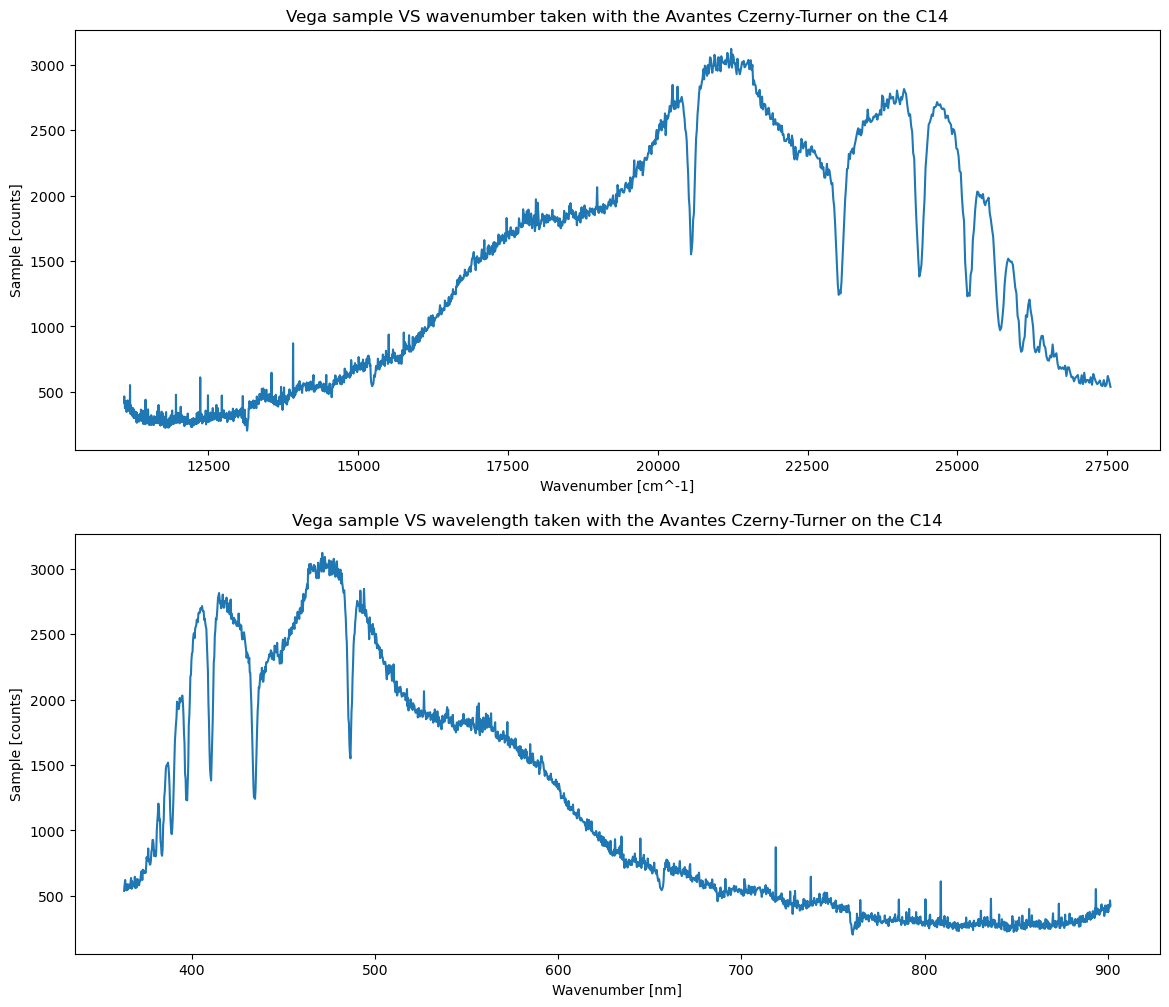

In [22]:
### STUDENT GENERATED CELL ###
#The first two lines remind you how to create a figure environment with two plots (in column)
# I've "named" the plots "pts" so any feature of the first plot needs to have pts[0]. and pts[1] for the second. 

plt.rcParams["figure.figsize"] = (14,12) # Change this layout to suit your viewing preferences
fig,pts = plt.subplots(2,1)                       

#create the plots by indexing pts
pts[0].plot (wavenumber, sample, label = "wavenumber")
pts[1].plot (wavelength, sample, label = "wavelength")

#adding chart elements 
pts[0].set_title('Vega sample VS wavenumber taken with the Avantes Czerny-Turner on the C14')
pts[0].set_xlabel('Wavenumber [cm^-1]')
pts[0].set_ylabel('Sample [counts]')

pts[1].set_title('Vega sample VS wavelength taken with the Avantes Czerny-Turner on the C14')
pts[1].set_xlabel('Wavenumber [nm]')
pts[1].set_ylabel('Sample [counts]')


<div class='alert alert-success'> 
    If you have done this correctly you should be seeing the spectrum of Vega taken with the Avantes Czerny-Turner on the C14. **More precisely, this is an average of 10 spectra taken with 1s integration time.** <br>
You can see the relatively short wavenumber dominance of the signal due to Vega's spectral type, together with the <a href='https://en.wikipedia.org/wiki/Balmer_series'> Balmer series</a>. 

The dominance of absorption lines $\beta$ and $\gamma$ help to pinpoint the temperature of the star, this method is referred to as the <a href='https://image.slideserve.com/248329/the-balmer-thermometer-l.jpg'>Balmer Thermometer</a>.</div>

We have sucessfully plotted the spectrum of Vega in respect to wavenumber and to wavelength. For clarification, we will proceed using the data in terms of wavelength (the second plot).

## Numpy's polyfit function(s)
<div class='alert alert-success'> 
We will focus on two spectral absorption lines: $H_{\gamma}$ around 435nm and $H_{\delta}$ around 410nm.

To begin with, consider only the second of the two lines. We will try and use only a few points which are part of the line and fit a 2nd order 
polynomial to it to identify its position.

As always, feel free to check the reference document on <a href='http://docs.scipy.org/doc/numpy/reference/generated/numpy.polyfit.html'>polyfit</a> in case you have forgotten how to use this.  

In our analysis, first you need to "zoom in" to the region of interest. You can do so by using <tt>np.where</tt> as you did last week on the wavelength vector to find the range of interest and use that to define a subset of wavelength and signal.

Try and isolate the line of interest excluding other lines and excessive amount of continuum features.
</div>

### Locating  $H_\delta$ and  $H_\gamma$ on spectral graphs

Let us show the position of  $H_\delta$ = 410 nm and  $H_\gamma$ = 435 nm on our graph of sample counts VS wavelength for visual aid to the user.

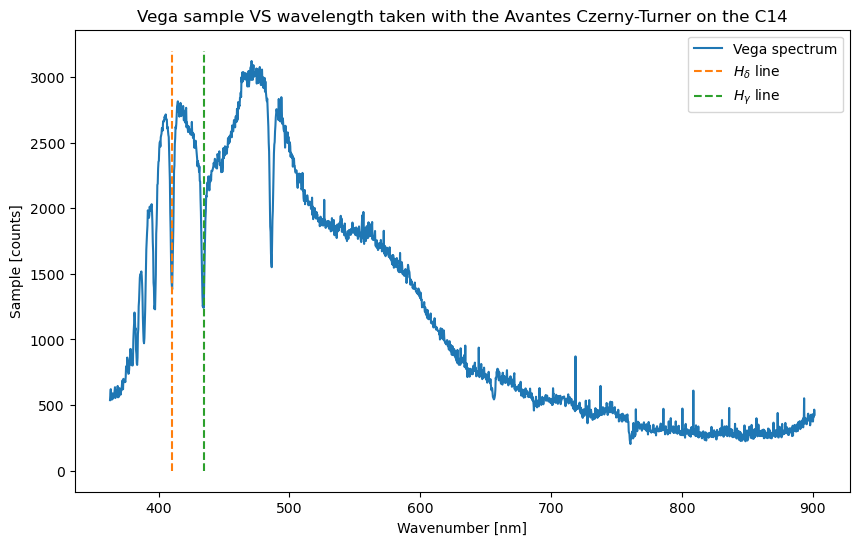

In [29]:
#plotting spectral lines on graph
plt.figure(figsize=(10,6))
plt.plot (wavelength, sample, label = "Vega spectrum")
plt.plot((410,410), (0,3200), "--" , label = '$H_\delta$ line')
plt.plot((435,435), (0,3200), "--" , label = '$H_\gamma$ line')
plt.title('Vega sample VS wavelength taken with the Avantes Czerny-Turner on the C14')
plt.xlabel('Wavenumber [nm]')
plt.ylabel('Sample [counts]')
plt.legend()

Now with a clearly marked plot we can proceed with the task.

### Polyfit on $H_\delta$ line

Let us start by applying fitting the $H_\delta$ line. To do this we will first use np.where() to index wavelengths in the range of this spectral line. We then plot the selected slice of data. Please note that we choose to plot the data as points instead of a line as really the data is a series of data points and hence should be visualized appropriately.

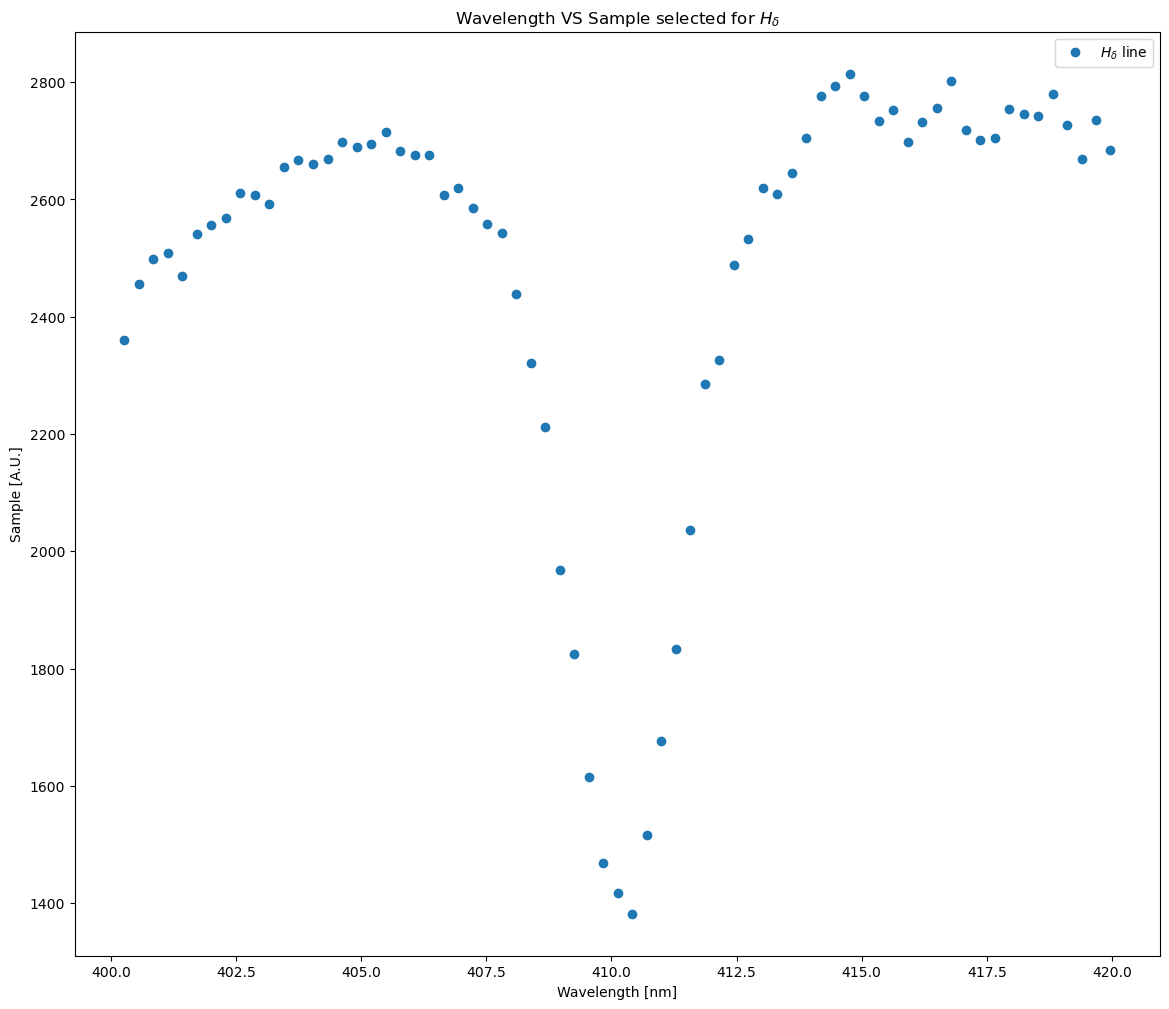

In [34]:
### STUDENT GENERATED CELL ###

#using np.where to create a subset for H-delta data
wavelength_delta1 = np.where(400 < wavelength)
wavelength_delta = np.where(wavelength[wavelength_delta1] < 420)

#plot for visual confirmation
plt.plot (wavelength[wavelength_delta], sample [wavelength_delta], 'o', label = '$H_\delta$ line')
plt.title('Wavelength VS Sample selected for $H_\delta$')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

The graph above shows data points that make up the spectral line of $H_\delta$. We will now take a half maximum of this spectral line to create an clear cut dip in the spectrum. 

<div class="alert alert-success"> 
    Now use the same <tt> np.where</tt> to narrow in a second (smaller) subset which acts on both conditions of wavelength as well as on signal to isolate the datapoints of the lower half of the line to fit.

Fit a 2nd order polynomial to this set of data, then use the coefficients to overplot the fit to the dataset.</div>

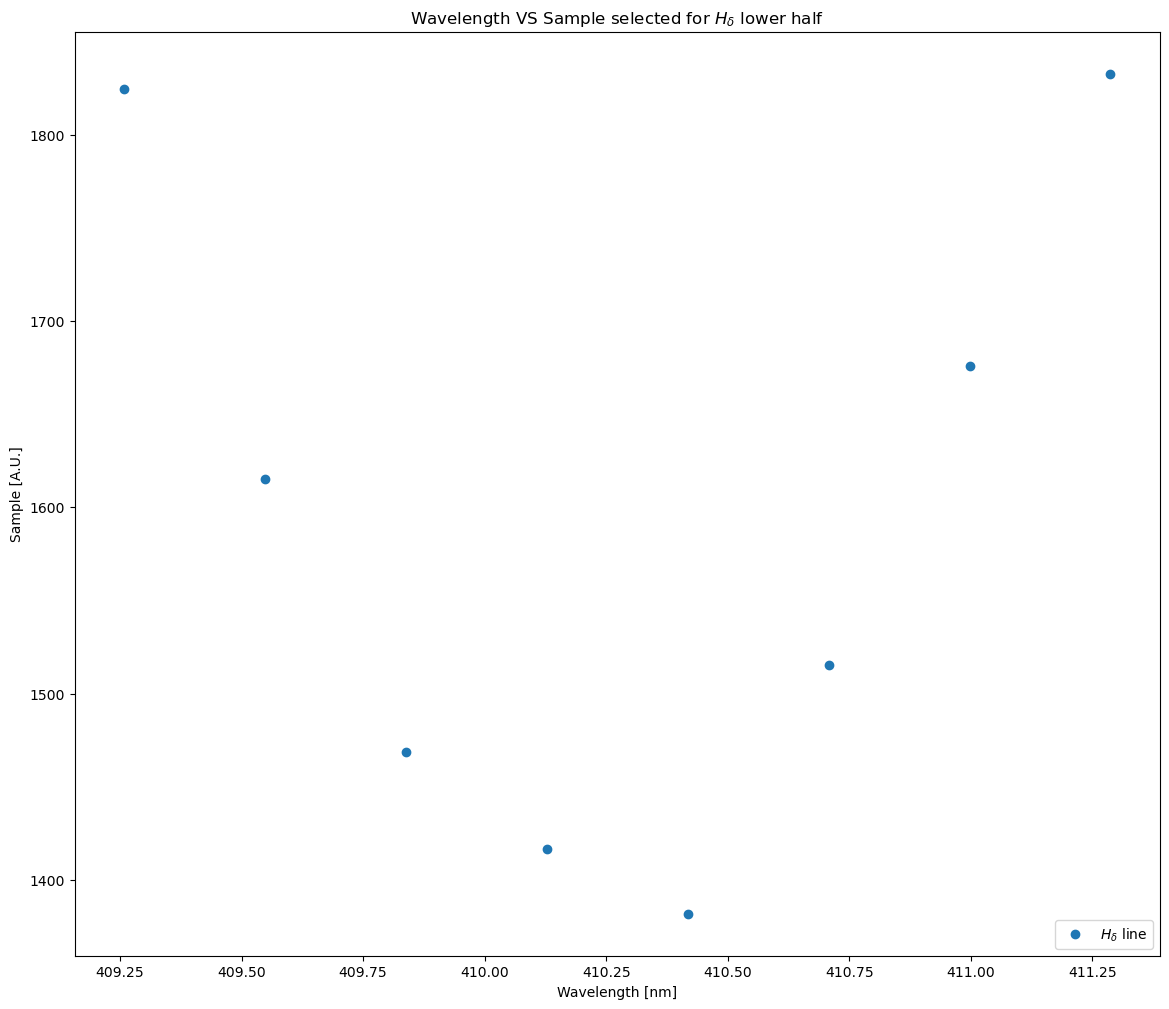

In [38]:
### STUDENT GENERATED CELL ###

#cutting the wavelength of the spectral line 
wavelength_half1 = np.where (wavelength>409)
wavelength_half2 = np.where (wavelength[wavelength_half1]<411.5)


#plot for visual confirmation
plt.plot (wavelength[wavelength_half2], sample [wavelength_half2], "o", label = '$H_\delta$ line')
plt.title('Wavelength VS Sample selected for $H_\delta$ lower half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend(loc = 'lower right')


The graph above shows us the data points in the lower half of the spectral line for label $H_\delta$. This visual confirmation is useful as we know that the lower half is made of 8 data points. This will be crucial when plotting the polyfit for the data in the next section.

<div class="alert alert-success"> 
    The vertex (minima) of the parabola $ax^2+bx+c = 0$ can be found as $x_v = -b/2a$. Use this to calculate the exact position of the $H_{\delta}$  line position.</div>

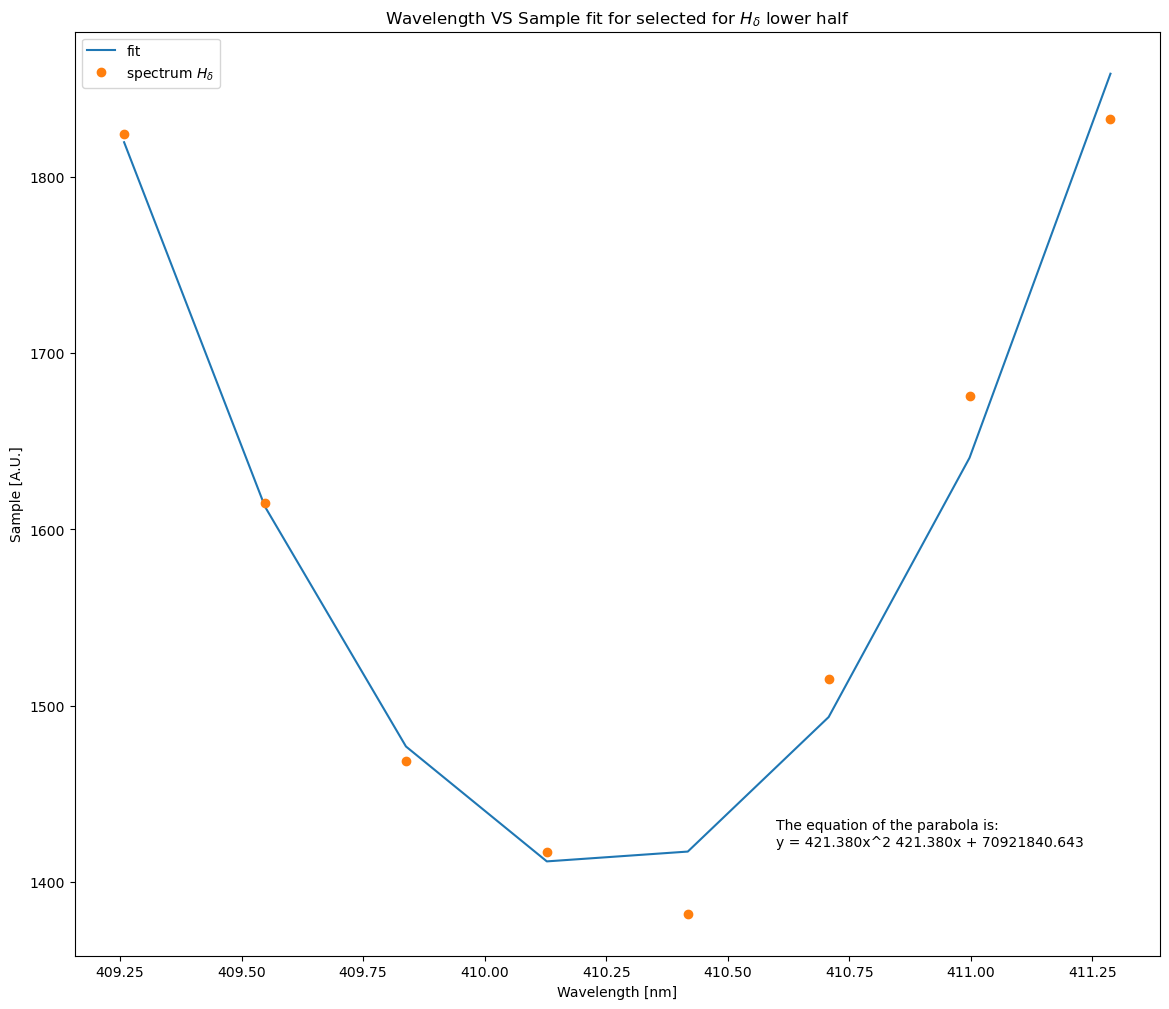

In [42]:
### STUDENT GENERATED CELL ###

#np.polyfit
degree = 2 #as its a parabola
coeffs_delta, error_delta = np.polyfit (wavelength[wavelength_half2], sample[wavelength_half2], degree, cov = "unscaled")

#unpack coeffs of the quadratic
a_delta = coeffs_delta[0]
b_delta = coeffs_delta[1]
c_delta = coeffs_delta [2]

#unpack errors
a_d_error, b_d_error, c_d_error = np.sqrt(np.diag(error_delta)) 

#x-line for fit 
x = wavelength[wavelength_half2]
y_line = (a_delta * x**2) + b_delta*x + c_delta

#plot
plt.plot (x, y_line, label = "fit")
plt.plot (wavelength[wavelength_half2], sample [wavelength_half2], "o", label = "spectrum $H_\delta$")
plt.title('Wavelength VS Sample fit for selected for $H_\delta$ lower half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(410.60, 1430,f"The equation of the parabola is:")
plt.text(410.60, 1420,f"y = {a_delta:.3f}x^2 {a_delta:.3f}x + {c_delta:.3f}")
plt.legend()


In [44]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit are:")
print (f"a: {a_delta:.3f} ± {a_d_error:.3f}")
print (f"b: {b_delta:.3f} ± {b_d_error:.3f}")
print (f"c: {c_delta:.3f} ± {c_d_error:.3f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit are:
a: 421.380 ± 0.918
b: -345742.467 ± 753.413
c: 70921840.643 ± 154552.217


Lastly, we calculate the vertex of the fit by using: 
$$
x_v = \frac{-b}{2a}
$$
Additionally, we propagate the calculated errors to the value of the vertex too by taking the partial derivative and adding in quadrature [1]:
$$
\Delta x_{vertex} = \sqrt{\frac{\Delta b^2}{4a^2} + \frac{b^2 \Delta a^2}{4 \Delta a^4}}
$$

In [47]:
#searching for the vertex delta
vertex_delta = (-b_delta) / (2*a_delta)

#error propagation 
vertex_err = np.sqrt ((b_d_error**2)/(4*a_delta**2) + ((b_delta**2)*(a_d_error**2))/ (4*a_delta**4))

print (f"The exact position of the H delta line is: {vertex_delta:.3f} ± {vertex_err:.3f} nm")

The exact position of the H delta line is: 410.250 ± 1.264 nm


### Polyfit on $H_\gamma$ line

We now repeat the same procedure for the $H_\gamma$ line with the ultimate goal of also obtaining a second degree polyfit from the spectral line:

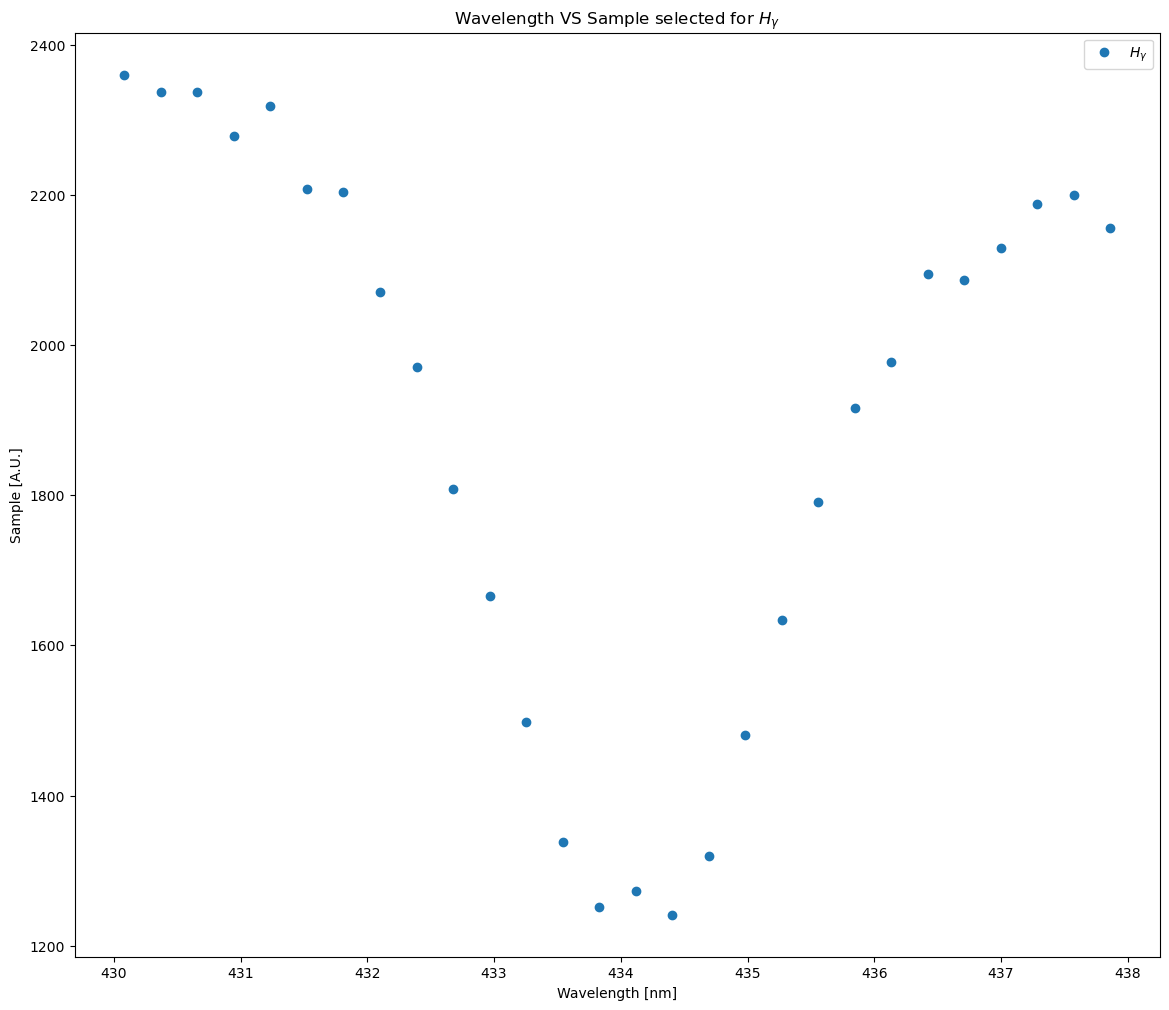

In [51]:
#using np.where to create a subset for H-gamma data
wavelength_gamma1 = np.where(430 < wavelength)
wavelength_gamma = np.where(wavelength[wavelength_gamma1] < 438)

#plot for visual confirmation
plt.plot (wavelength[wavelength_gamma], sample [wavelength_gamma], 'o', label = "$H_\gamma$")
plt.title('Wavelength VS Sample selected for $H_\gamma$')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend ()

We now again narrow down the subset of the data points by only picking the lower half of the spectral line:

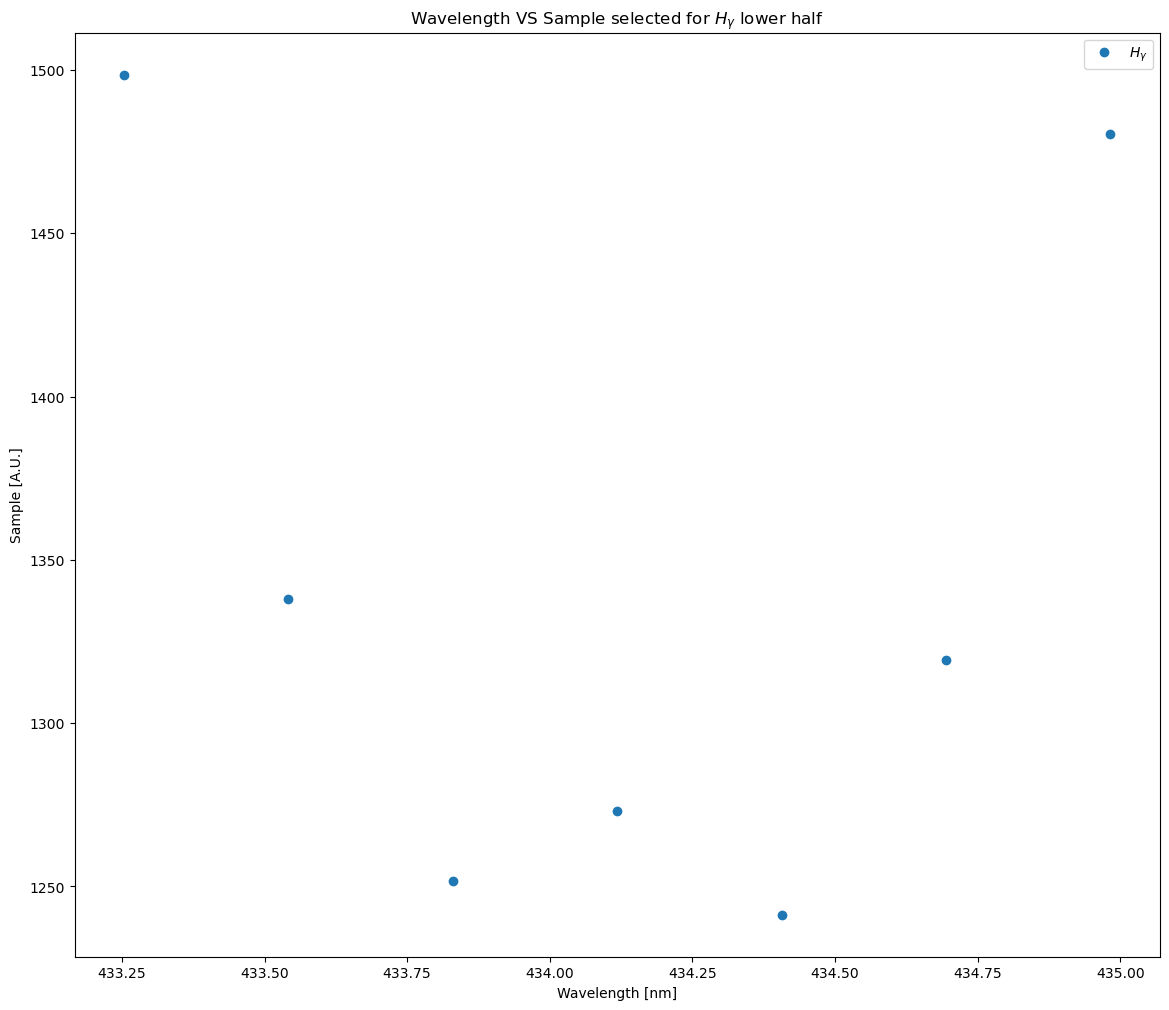

In [54]:
#plotting the lower half of the line
wavelength_half_gamma1 = np.where (wavelength>433)
wavelength_half_gamma2 = np.where (wavelength[wavelength_half_gamma1]<435.2)


#plot for visual confirmation
plt.plot (wavelength[wavelength_half_gamma2], sample [wavelength_half_gamma2], "o", label = "$H_\gamma$")
plt.title('Wavelength VS Sample selected for $H_\gamma$ lower half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

We proceed with fitting a second degree fit to this part:

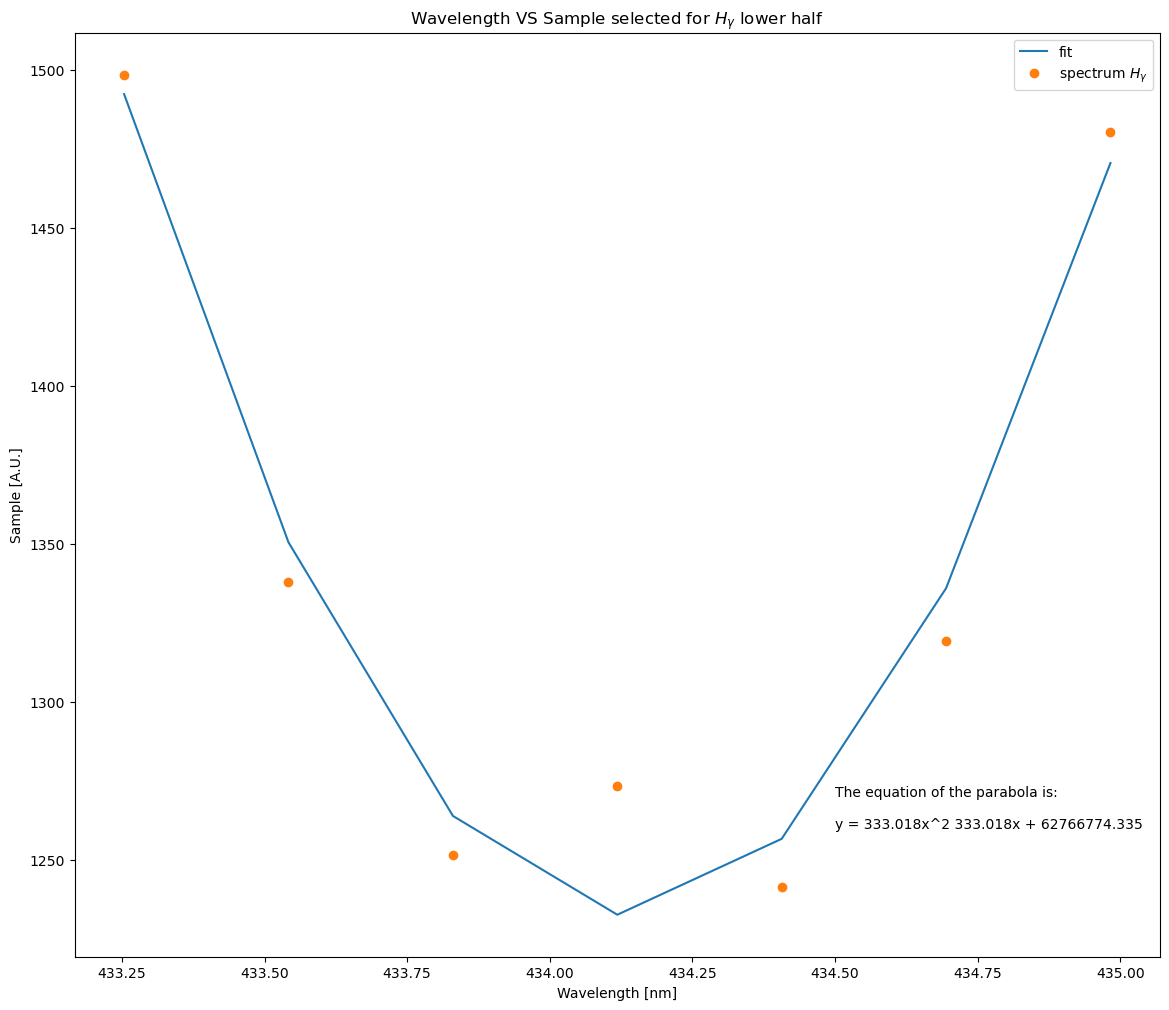

In [57]:
#np.polyfit
degree = 2
coeffs_gamma, error_gamma = np.polyfit (wavelength[wavelength_half_gamma2],sample [wavelength_half_gamma2], degree, cov = "unscaled")

#unpack coeffs 
a_gamma = coeffs_gamma[0]
b_gamma= coeffs_gamma[1]
c_gamma = coeffs_gamma[2]

#unpack errors
a_g_error, b_g_error, c_g_error = np.sqrt(np.diag(error_gamma)) 

#lines for fit 
x_gamma= wavelength[wavelength_half_gamma2]
y_line_gamma = (a_gamma * x_gamma**2) + b_gamma*x_gamma + c_gamma

#plot
plt.plot (x_gamma, y_line_gamma, label = "fit")
plt.plot (wavelength[wavelength_half_gamma2], sample[wavelength_half_gamma2], "o", label = "spectrum $H_\gamma$")
plt.title('Wavelength VS Sample selected for $H_\gamma$ lower half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(434.50, 1270,f"The equation of the parabola is:")
plt.text(434.50, 1260,f"y = {a_gamma:.3f}x^2 {a_gamma:.3f}x + {c_gamma:.3f}")
plt.legend()

In [59]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit are:")
print (f"a: {a_gamma:.3f} ± {a_g_error:.3f}")
print (f"b: {b_gamma:.3f} ± {b_g_error:.3f}")
print (f"c: {c_gamma:.3f} ± {c_g_error:.3f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit are:
a: 333.018 ± 1.314
b: -289150.662 ± 1140.634
c: 62766774.335 ± 247584.760


Lastly, we calculate the vertex of the fit by using: 
$$
x_v = \frac{-b}{2a}
$$
Additionally, we propagate the calculated errors to the value of the vertex too by taking the partial derivative and adding in quadrature [1]:
$$
\Delta x_{vertex} = \sqrt{\frac{\Delta b^2}{4a^2} + \frac{b^2 \Delta a^2}{4 \Delta a^4}}
$$

In [62]:
#searching for the vertex gamma
vertex_gamma = (-b_gamma) / (2*a_gamma)

#error on gamma vertex
vertex_err_gamma = np.sqrt ((b_g_error**2)/(4*a_gamma**2) + ((b_gamma**2)*(a_g_error**2))/ (4*a_gamma**4))

print (f"The exact position of the H delta line is: {vertex_gamma:.3f} ± {vertex_err_gamma:.3f} nm")



The exact position of the H delta line is: 434.137 ± 2.422 nm


### Comupting the speed of Vega

<div class="alert alert-success"> 
    The H gamma ($H_{\gamma}$) line is at rest is 434.0472 nm. 
This is likely to not coincide exactly with the result of your fit.
Aside from the errors which might be in the measurement (due to errors in the calibration of the spectrometer), let's assume that the spectrometer is correct and there is an astrophysical reason for this: a Doppler shift. 
Calculate the speed at which this star is going in order to get this result.</div>


We compute the doppler shift by:
$$
v_{\gamma} = \frac{c \Delta \lambda_{\gamma}}{\lambda_0} 
$$

Where:
- c = speed of light
- $\Delta \lambda_{\gamma}$ = difference in rest and the computed vertex wavelength
- $\lambda_0$ = rest wavelength

Where we use the rest wavelength values:
- $\lambda_{0g}$ rest = 434.0472 nm (as stated above)
- $\lambda_{0d}$ rest = 410.2 nm [2]

The error for $\Delta v_{\gamma}$ is propagated and added in quadrature to give:
$$
\Delta v_{\gamma} = \frac{c}{\lambda_{0g}} * \Delta \lambda_{\gamma}
$$

We then apply both formulas to delta.

In [67]:
### STUDENT GENERATED CELL ###

# Doppler shift calculation for rest wavelength of Hgamma
c = 3*10**8
rest_hgamma = 434.0472
star_speed_gamma = ((c *(vertex_gamma - rest_hgamma))/(rest_hgamma) / 1000)

#error on h-gamma
err_star_speed_gamma = (((c/rest_hgamma) * vertex_err_gamma) /1000)

# Doppler shift calculation for rest wavelength of H delta
c = 3*10**8
rest_hdelta = 410.174
star_speed_delta = ((c *(vertex_delta - rest_hdelta))/(rest_hdelta) / 1000)

#error
err_star_speed_delta = (((c/rest_hdelta) * vertex_err) /1000)

print (f"The speed of the star from the H gamma line is: {star_speed_gamma:.3f} ± {err_star_speed_gamma:.3f} km/s")
print (f"The speed of the star from the H delta line is: {star_speed_delta:.3f} ± {err_star_speed_delta:.3f} km/s")

The speed of the star from the H gamma line is: 62.264 ± 1674.010 km/s
The speed of the star from the H delta line is: 55.636 ± 924.667 km/s


The errors on these estimates are very large, we will try computing the velocities using a differnet method later in this task and we will see if that approach reduces them. If not a reevalution of our chosen points for fitting will be deemed necessary.

### Continuum for $H_\delta$

<div class="alert alert-success"> 
<b>It is possible that the continuum slope is affecting our fit, so let us correct for this and repeat our fit.</b>

To do this we need to use np.where to identify the sets of "x" and "y" portions of the axes that we need to fit (ignoring the spectral line) in order to best fit the continuum region. The fitting function used can still be a second order polynomial as true physics affecting this continuum is likely to be a combination of excessively complex actors: blackbody law emission of the star, atmospheric transmission and optical efficiency of telescope and detector (all non linear functions of wavelength).
</div>

In this section we will extract data points of the spectrum surrounding the spectral lines and excluding the spectral line itself as to plot a continuum fit. Again we start with $H_\delta$ and then apply the same procedure for $H_\gamma$.

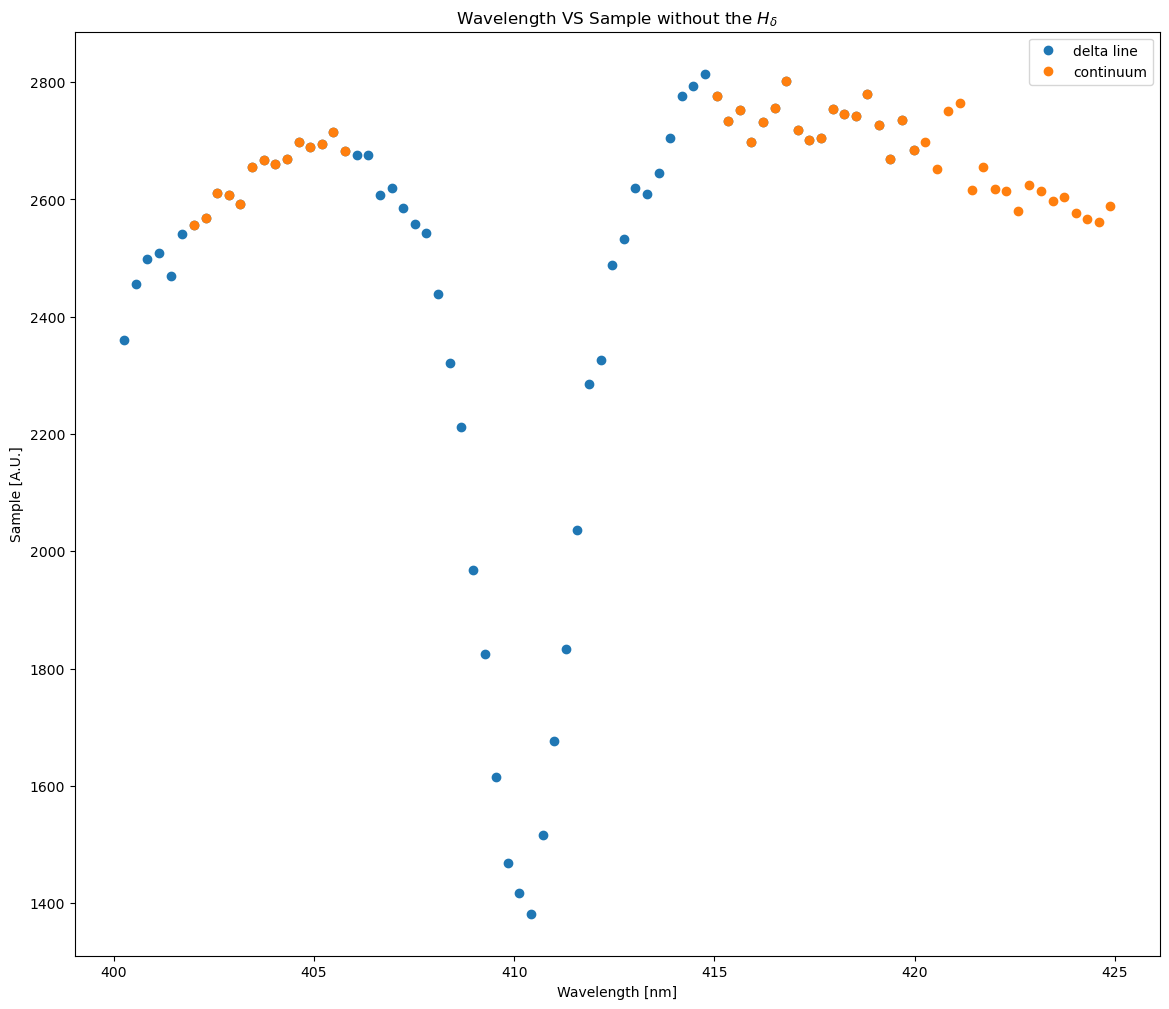

In [73]:
### STUDENT GENERATED CELL ###

#using np.where to exclude the delta line and just use wings 
continuum_delta = np.where (((402 < wavelength) & (wavelength < 406)) | ((415 < wavelength) & (wavelength < 425)))

#plotting the continuum
plt.plot (wavelength[wavelength_delta], sample [wavelength_delta], 'o', label = "delta line")
plt.plot (wavelength[continuum_delta], sample[continuum_delta], 'o', label = "continuum")
plt.title('Wavelength VS Sample without the $H_\delta$')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()


Having identified the data points we will now plot a second degree fit to the data.

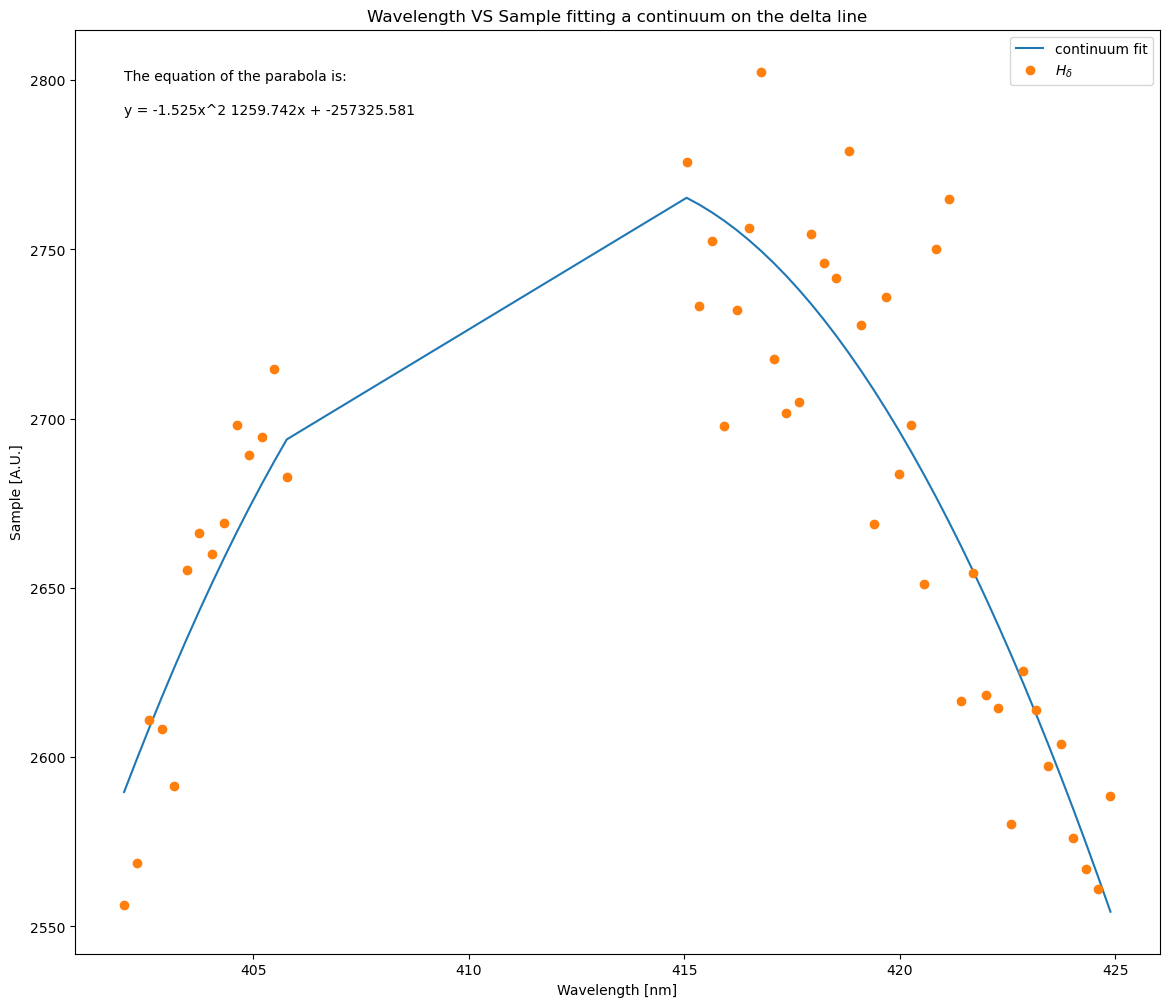

In [76]:
#np.polyfit
degree = 2
coeffs_delta_cont, error_delta_cont = np.polyfit (wavelength[continuum_delta], sample[continuum_delta], degree, cov = "unscaled")

#check the amount of coeffs found
len(coeffs_delta_cont)

#unpack coeffs 
a_delta_cont = coeffs_delta_cont[0]
b_delta_cont = coeffs_delta_cont[1]
c_delta_cont = coeffs_delta_cont[2]

#unpack errors
a_d_error_con, b_d_error_con, c_d_error_con = np.sqrt(np.diag(error_delta_cont)) 

#x-line for fit 
x_delta_cont = wavelength[continuum_delta]
y_line_delta_cont = (a_delta_cont * x_delta_cont **2) + b_delta_cont*x_delta_cont  + c_delta_cont

#plot
plt.plot (x_delta_cont, y_line_delta_cont, label = "continuum fit")
plt.plot (wavelength[continuum_delta], sample[continuum_delta], "o", label = "$H_\delta$")
plt.title('Wavelength VS Sample fitting a continuum on the delta line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(402, 2800,f"The equation of the parabola is:")
plt.text(402, 2790,f"y = {a_delta_cont:.3f}x^2 {b_delta_cont:.3f}x + {c_delta_cont:.3f}")
plt.legend()

In [78]:
#printing the equation of the parabola 

#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the delta continuum are:")
print (f"a: {a_delta_cont:.3f} ± {a_d_error_con:.3f}")
print (f"b: {b_delta_cont:.3f} ± {b_d_error_con:.3f}")
print (f"c: {c_delta_cont:.3f} ± {c_d_error_con:.3f}")


For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the delta continuum are:
a: -1.525 ± 0.004
b: 1259.742 ± 3.041
c: -257325.581 ± 627.652


While we see that the fit is not a perfect parabola, this is due to the exclusion of the spectral line. We see that we were still able to sucessfully complete the polyfit. 

<div class="alert alert-success"> 
Now "normalise the spectrum" of the continuum and attempt to replot the line.
To perform this operation, one can go in different ways, but the accepted practice is to "normalize" the data set so that the continuum line is equal to 1 everywhere (thus not affecting values of 0 in the original data set).
This can be done by performing a ratio between the two.
</div>

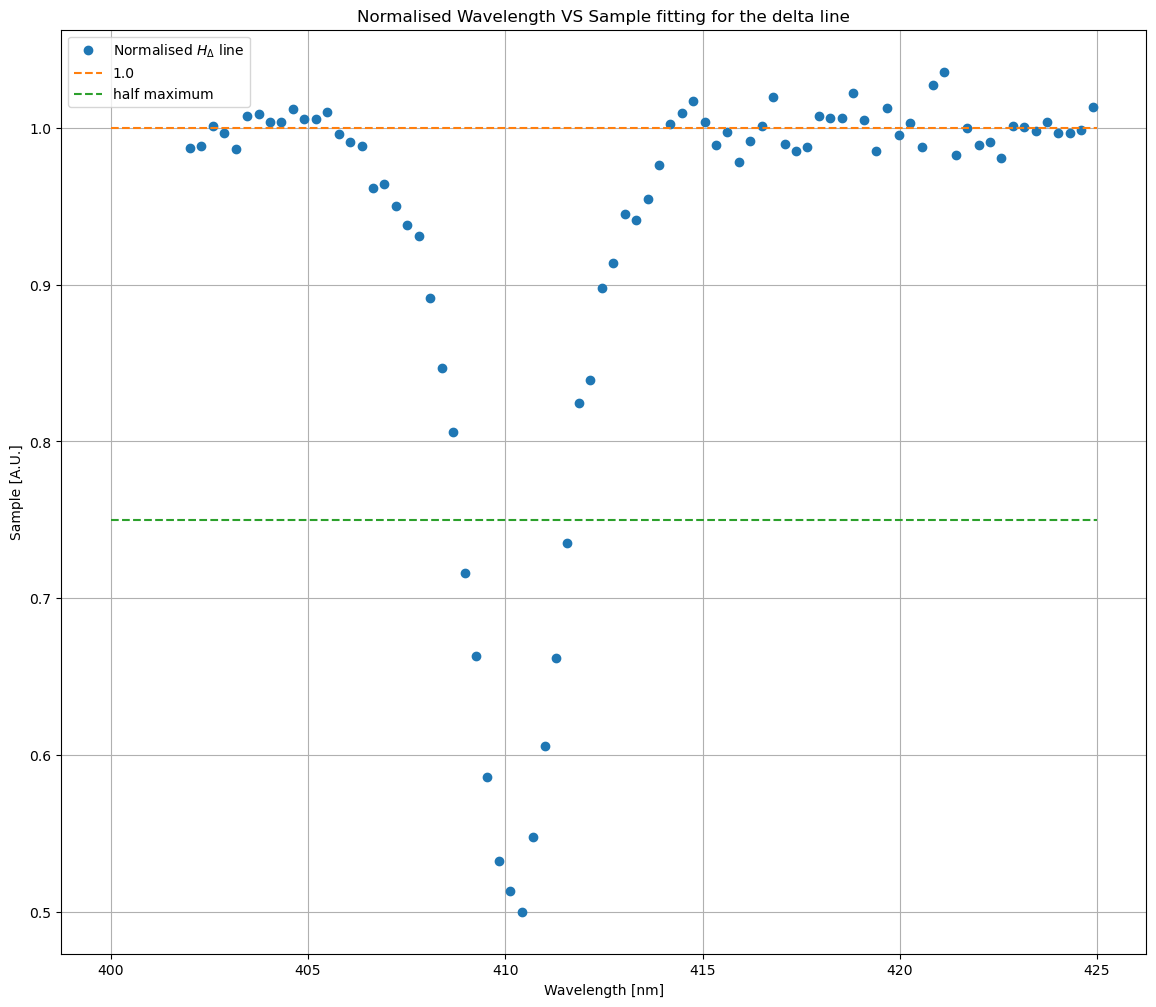

In [82]:
#to normalize we plug it into the model fitted 

#find wavelength range
wavelength_range = np.where((402< wavelength) & (425>wavelength))[0]

#use the fitted model
y_fitted_delta = a_delta_cont* (wavelength[wavelength_range])**2 + b_delta_cont * wavelength[wavelength_range] + c_delta_cont

#find the ratio
y_normalized_delta = sample[wavelength_range]/y_fitted_delta

#plot wings which should be around 1 
plt.plot(wavelength[wavelength_range], y_normalized_delta, 'o', label = "Normalised $H_{\Delta}$ line")
plt.title('Normalised Wavelength VS Sample fitting for the delta line')
plt.plot((400,425), (1,1), "--" , label = '1.0')
plt.plot((400,425), (0.75,0.75), "--" , label = 'half maximum')
plt.grid({'x'})
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()


We see that the fit has been sucessfully normalised this spectral line as the wings of the line all reside in the viscinity of 1.0. The spectral line is plotted as comparison. We also plot the half maximum as this will be useful when it comes to estimating fit coefficients for the lorentzian in later sections.

## Continuum for $H_\gamma$

We now repeat the procedure for fitting a continuum but this time to the  $H_\gamma$ line. Let us start with identifying the region of wavelengths again.

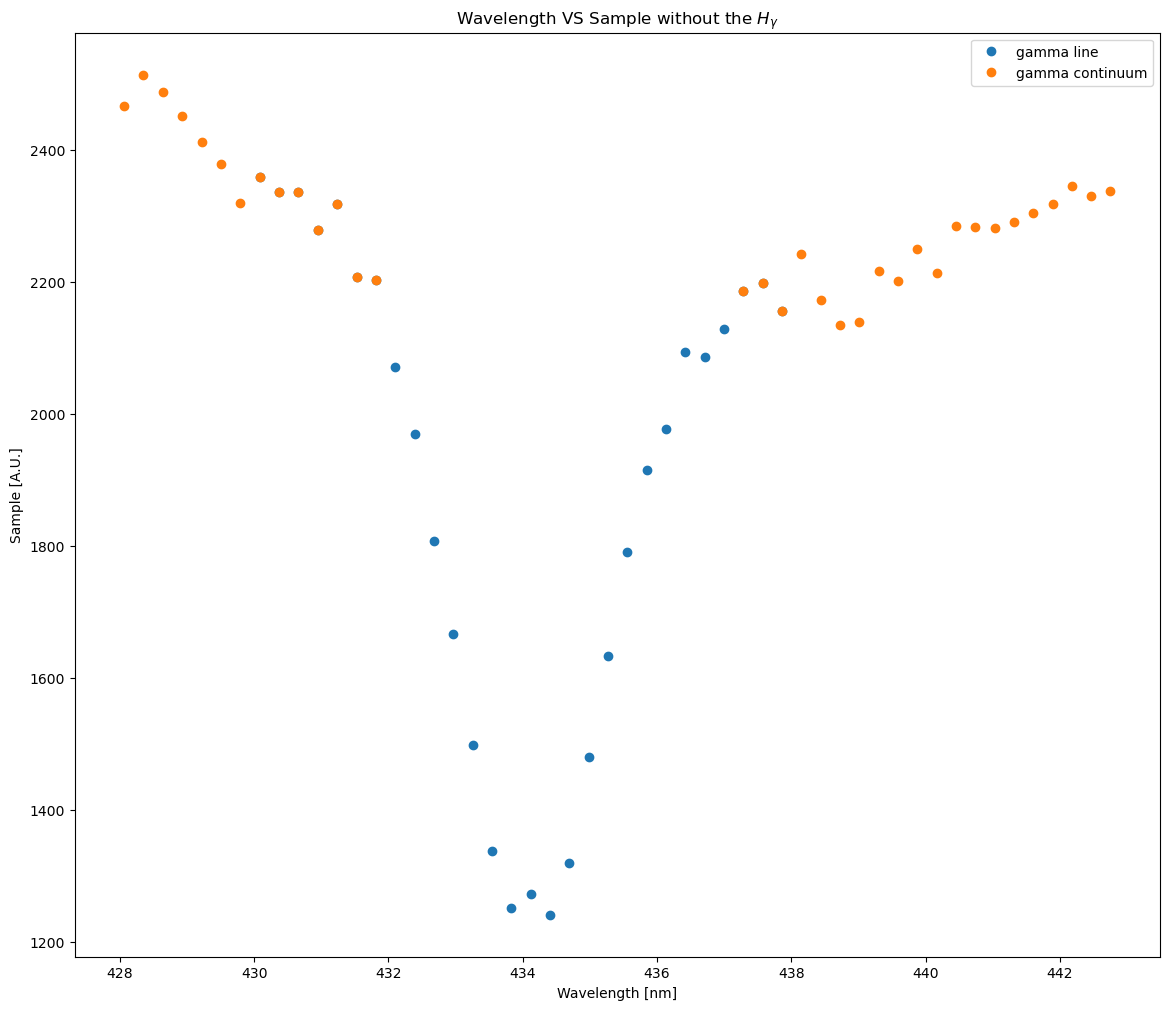

In [87]:
#using np.where to exclude the gamma line and just use wings 
continuum_gamma = np.where (((428 < wavelength) & (wavelength < 432)) | ((437 < wavelength) & (wavelength < 443)))

#plotting the continuum
plt.plot (wavelength[wavelength_gamma], sample [wavelength_gamma], 'o', label = "gamma line")
plt.plot (wavelength[continuum_gamma], sample[continuum_gamma], 'o', label = "gamma continuum")
plt.title('Wavelength VS Sample without the $H_\gamma$')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

Having identified the data points we will now plot a second degree fit to the data.

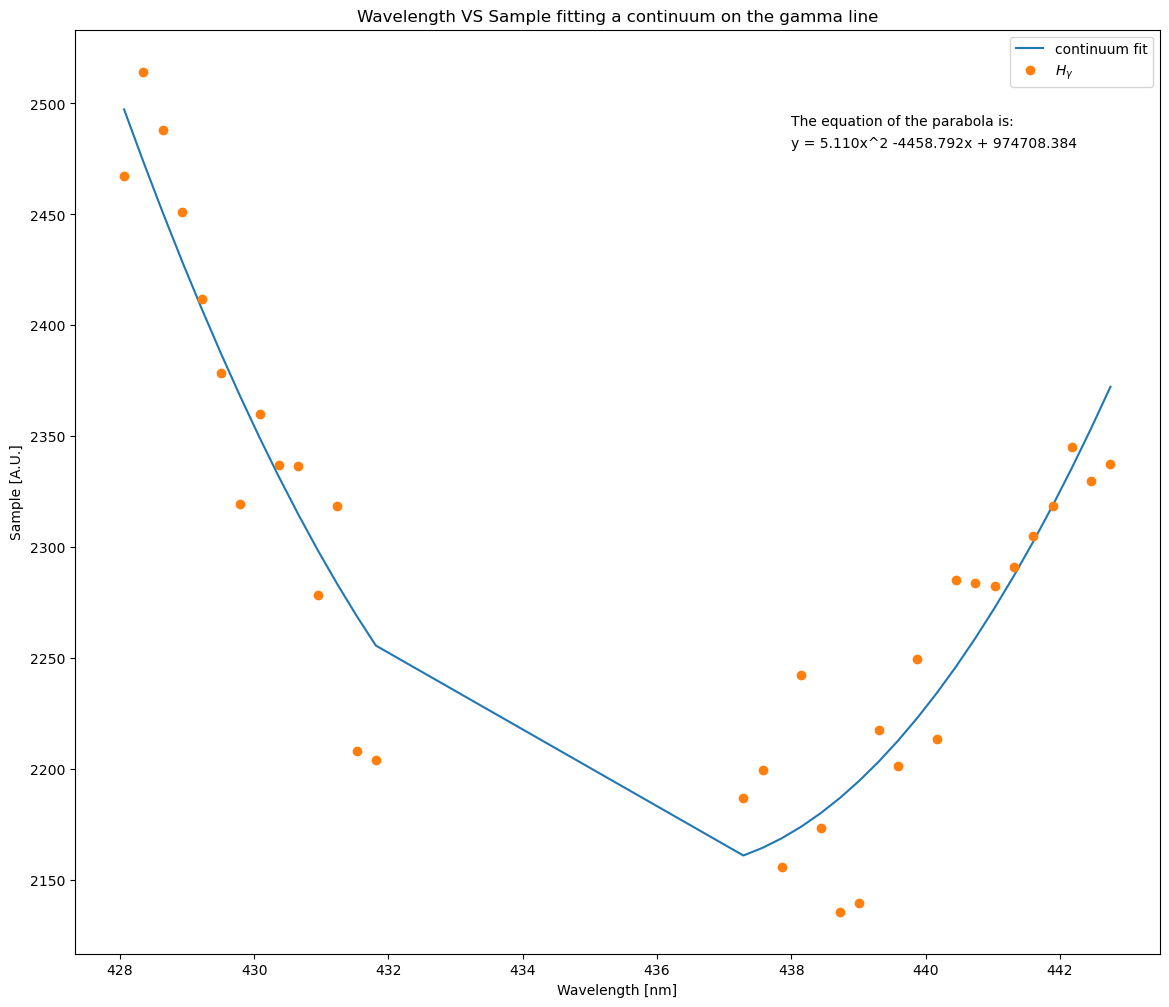

In [90]:
#np.polyfit
degree = 2
coeffs_gamma_cont, error_gamma_cont = np.polyfit (wavelength[continuum_gamma], sample[continuum_gamma], degree, cov = "unscaled")

#unpack coeffs 
a_gamma_cont = coeffs_gamma_cont[0]
b_gamma_cont = coeffs_gamma_cont[1]
c_gamma_cont = coeffs_gamma_cont[2]

#unpack errors
a_g_error_con, b_g_error_con, c_g_error_con = np.sqrt(np.diag(error_gamma_cont)) 

#x-line for fit 
x_gamma_cont = wavelength[continuum_gamma]
y_line_gamma_cont = (a_gamma_cont * x_gamma_cont **2) + b_gamma_cont*x_gamma_cont  + c_gamma_cont

#plot
plt.plot (x_gamma_cont, y_line_gamma_cont, label = "continuum fit")
plt.plot (wavelength[continuum_gamma], sample[continuum_gamma], "o", label = "$H_\gamma$")
plt.title('Wavelength VS Sample fitting a continuum on the gamma line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(438, 2490,f"The equation of the parabola is:")
plt.text(438, 2480,f"y = {a_gamma_cont:.3f}x^2 {b_gamma_cont:.3f}x + {c_gamma_cont:.3f}")
plt.legend()

In [92]:
#printing the equation of the fit

#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the delta continuum are:")
print (f"a: {a_gamma_cont:.3f} ± {a_g_error_con:.3f}")
print (f"b: {b_gamma_cont:.3f} ± {b_g_error_con:.3f}")
print (f"c: {c_gamma_cont:.3f} ± {c_g_error_con:.3f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the delta continuum are:
a: 5.110 ± 0.012
b: -4458.792 ± 10.100
c: 974708.384 ± 2197.696


Now let us normalize this fit using the same procedure as beforehand:

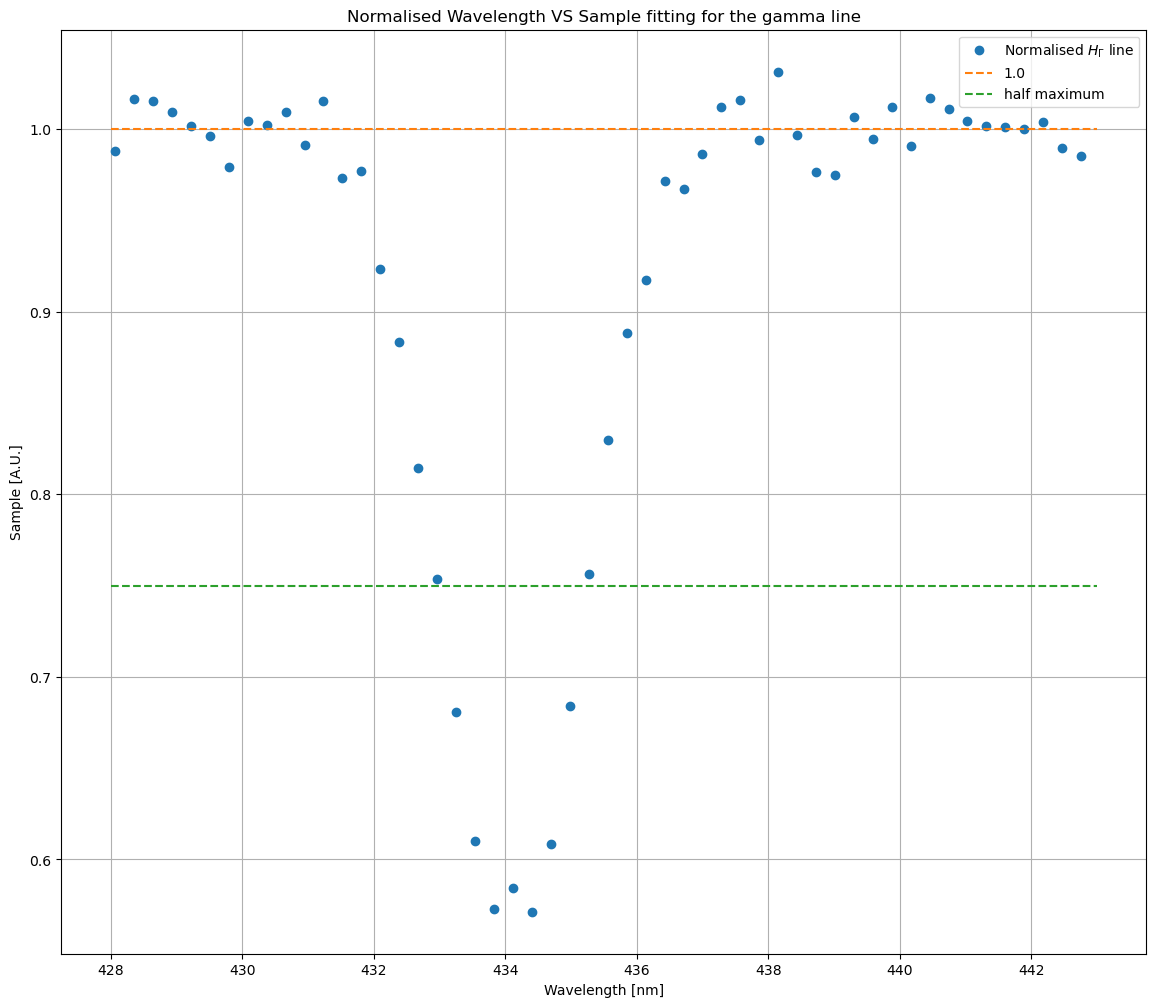

In [95]:
#to normalize we plug it into the model fitted 

#find wavelength range
wavelength_range_gamma = np.where((428< wavelength) & (443>wavelength))[0]

#use the fitted model
y_fitted_gamma = a_gamma_cont* (wavelength[wavelength_range_gamma])**2 + b_gamma_cont * wavelength[wavelength_range_gamma] + c_gamma_cont

#find the ratio
y_normalized_gamma= sample[wavelength_range_gamma]/y_fitted_gamma

#plot wings which should be around 1 
plt.plot(wavelength[wavelength_range_gamma], y_normalized_gamma, 'o', label = "Normalised $H_{\Gamma}$ line")
plt.title('Normalised Wavelength VS Sample fitting for the gamma line')
plt.plot((428,443), (1,1), "--" , label = '1.0')
plt.plot((428,443), (0.75,0.75), "--" , label = 'half maximum')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid({'x'})
plt.legend()

Again the plot above verifies that our data has sucessfully been normalised as the wings of the $H_{\Gamma}$ line are also around the value of 1.0. 

<div class="alert alert-success"> 
    Now however, technically we could perform the fit  on the entire subet if we used the appropriate line shape.</div>

### Part B : Fitting generic functions

Let us now introduce a way to fit a generic function previously defined by the user:

##### LINE PROFILES 
<div class="alert alert-success"> 

In astronomical spectroscopy, there are two main analytical expressions used for spectral profiles: Gaussian and Lorentzian. A third profile (Voigt) combines the former two and will be explained at the end.
The details on the physical causes tied to each functional form can be found in section 9.2 of <a href="https://www-cambridge-org.libproxy.ucl.ac.uk/core/services/aop-cambridge-core/content/view/EECFD38A81F393DD67CD040035A97F0D/9780511975349c9_p194-219_CBO.pdf/absorption_lines_and_radiative_transfer.pdf"> Atomic Astrophysics and Spectroscopy, Pradhan & Nahar </a>.

In short, while the inherent line width is due to the Uncertainty principle, this is then generally broadened either by Doppler effect of the molecules involed associated to a velocity distribution (Maxwellian) which takes the form of Gaussian function, or dampening and pressure broadening, both associated with a Lorentzian profile.

These line shapes can be parametrized as follows:
###### Gaussian ######
$$ G(x) = g_0 + g_1 \exp \left(\frac{-(x-g_2)^2}{2 g_3^2}\right) $$ 

The appropriate form for this is 
###### Lorentzian ######
$$ L(x) = l_0 + \frac{l_1}{1 + ((x - l_2)/l_3)^2} $$

where the $_0$ subscript element refers to the offset level (generally relevant to the context of the line (emission=0, absorption = level of continuum, in your case 1) and the $_1$ subscript is in both cases the amplitude of the line.

Line position are related to the $_2$ subscript and half-widths can be expressed in each case as a derivative of the $_3$ subscript quantities.

You can also find other definitions of the same <a href='https://en.wikipedia.org/wiki/Spectral_line_shape#:~:text=Spectral%20line%20shape%20describes%20the,maximum%20height%20and%20half%2Dwidth.' >line expressions</a>, with more focus on the line width... any such expression is fine as long as the relation between parameters is clear

As you are already very familiar with gaussians, here we will make use of Lorentzian line profiles.

So in the next cell, define a function that creates a Lorentzian function from an x and a set of relevant parameters.
    </div>

As it can be interpreted from the information above Gaussian, Lorentzian and Voight profile fits can be used to fit spectral lines. In this task we will proceed with using the Lorentzian. For simplification we will now create a function for the Lorentzian that takes as input an array for wavelength and then an estimate for the fit coefficients l0, l1, l2 and l3.

In [102]:
### STUDENT COMPLETED CELL ###

#lorentzian fit function

def lorentzian_function (x_l, l0, l1, l2, l3):
    """
    This function fits a lorentzian to a spectral line.
    Input: wavelength range for spectral line and estimates of l0, l1, l2, l3
    Output: A lorentzian fit
    """

    #mirroring the formula above
    lorentzian = l0 + (l1)/(1+ ((x_l - l2)/l3)**2)
    return lorentzian

<div class="alert alert-success"> 
Now fit the function to the the line.  This can be done by using the name of the function you used for its definition in the below cell code.
Once you have the parameters, you can create a Lorentzian fit according to those parameters. (this line just calls the same function you defined providing the exact parameters resulting from the fit.
</div>

### Lorentzian for $H_\delta$

We will now use the function defined above to fit a lorentzian to the $H_\delta$ spectral line. To do this we must assign an estimate of coeffs $l_0$, $l_1$, $l_2$ and $l_3$. See our estimates and a brief justification for each:

- $l_0$ = 1 => offset level, value provided in guidance cell above
- $l_1$ =  - 0.5 => amplitude of the spectral line can be deduced from normalised plot of $H_\delta$ 
- $l_2$ = 410.25 => calculated value of wavelength of  $H_\delta$  using polyfit
- $l_3$ = 1.5 => width of normalised spectral line at its half maximum

In [107]:
### STUDENT COMPLETED CELL ###

# Modify the command line below to use the function you've defined above to fit your data.
# The outputs are the parameters of the fit and the covariance matrix (similar to polyfit).
# In the parenthesis you have in order: 
# AAA)The name of the function used by you in the definition above
# BBB & CCC)The portion of x axis to fit and the portion of y axis to fit.
# pp) A first approximate guess to the parameters used (CHANGE THESE!)

#using our function and estimated values for the fit coefficients
line_par , line_cov = optimize.curve_fit(lorentzian_function, wavelength[wavelength_range], y_normalized_delta , p0=[1.0,-0.5,vertex_delta,1.5])
print(f"The coeffs of the lorentzian fit for the delta line are l0 = {line_par[0]:.3f}, l1 = {line_par[1]:.3f}, l2 = {line_par[2]:.3f}, l3 = {line_par[3]:.3f}")
 
line_shape_delta = lorentzian_function(wavelength[wavelength_range],line_par[0],line_par[1],line_par[2],line_par[3])


The coeffs of the lorentzian fit for the delta line are l0 = 1.019, l1 = -0.540, l2 = 410.250, l3 = 1.265


Upon inspection of these values, we see our estimates were appropriate. Nevertheless we will progress the task with the comupted coefficients as they are computed by the fit rather than estimated. Below we plot the the lorentzian over the normalised data points of the spectral line.

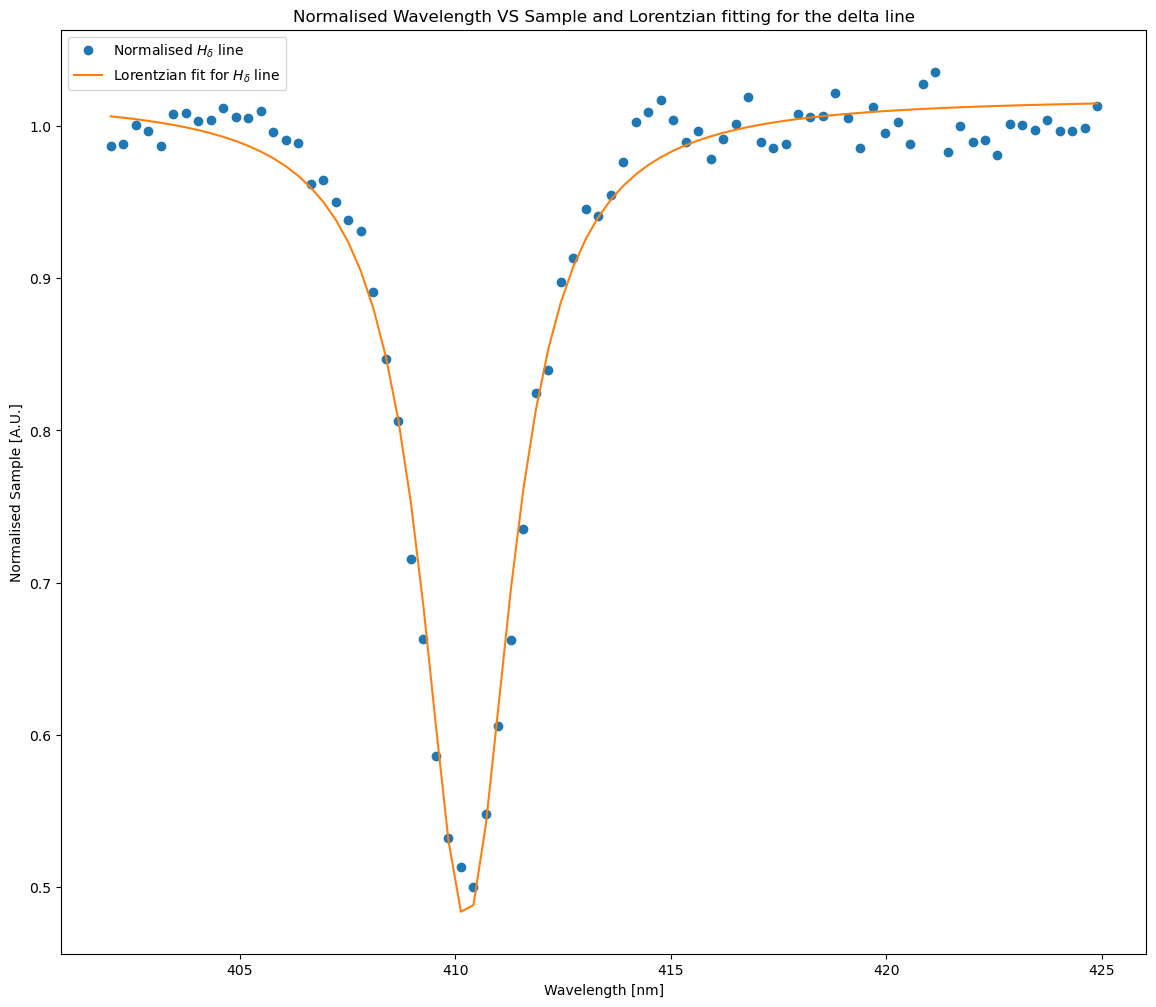

In [110]:
#plotting the lorentzian over the spectral line

plt.plot(wavelength[wavelength_range], y_normalized_delta, 'o', label = "Normalised $H_{\delta}$ line")
plt.plot (wavelength[wavelength_range], line_shape_delta, label = 'Lorentzian fit for $H_{\delta}$ line ' )
plt.title('Normalised Wavelength VS Sample and Lorentzian fitting for the delta line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Normalised Sample [A.U.]')
plt.legend()

<div class="alert alert-success"> 
    
**Revision: Errors on fit parameters from the matrix of covariance.**

What is the covariance matrix? <br>

**The quick answer:** The matrix of covariance allows us to calculate the errors on our fitted parameters. For $n$ parameters, the matrix of covariance is an $n \times n$ matrix, the diagonal elements of which are the *square* of the uncertainties of the fitted parameters. The off-diagonal elements give the level of correlation between the uncertainties in the parameters - we won't use them here.

**The long (and more complete answer)** is given in sections 7.2-7.4 of [Hughes and Hase]

When the cell below is complete, it will output the order of each coefficient, the corresponding coefficient and its error, with appropriate text strings.

Look at how we do this:

1. This is most easily done using a loop over the elements of `p`. For example, the length of an array `p` is given by `len(p)` or `np.size(p)`. The structure  `for i in range(np.size(p)):` sets up a loop that will iterate the same number of times as there are elements in the array.
2. Remember that `np.polyfit` gives the coefficients largest-order first. So for a loop with increasing index i, the order of the coefficient `p(i)` will be given by `len(p)-i-1`.

<p>
You will need to complete the final line of this cell to calculate the error of each coefficient.

You'll probably want to use `np.diag` to extract the diagonal elements of the matrix of covariance in the form of a 1d array. You can find out more about this numpy function here: http://docs.scipy.org/doc/numpy/reference/generated/numpy.diag.html <div>


In [113]:
### STUDENT COMPLETED CELL ###
# Plot the data points and the resulting Fit.
# Print the parameters and the relevant uncertainties.
l0_err, l1_err, l2_err, l3_err = np.sqrt(np.diag(line_cov)) 
print (f"The value for l_0 for the delta line as found by the lorentzian is {line_par[0]:.3f} ± {l0_err:.3f}")
print (f"The value for l_1 the delta line as found by the lorentzian is {line_par[1]:.3f} ± {l1_err:.3f}")
print (f"The value for l_2 the delta line as found by the lorentzian is {line_par[2]:.3f} ± {l2_err:.3f}")
print (f"The value for l_3 the delta line as found by the lorentzian is {line_par[3]:.3f} ± {l3_err:.3f}")


The value for l_0 for the delta line as found by the lorentzian is 1.019 ± 0.003
The value for l_1 the delta line as found by the lorentzian is -0.540 ± 0.010
The value for l_2 the delta line as found by the lorentzian is 410.250 ± 0.023
The value for l_3 the delta line as found by the lorentzian is 1.265 ± 0.038


<div class="alert alert-success"> 
Now comment on the results and compare them according to the uncertainty found.
</div>

As mentioned, the results show that our reasoning for the estimate of these parameters was reasonable, showing our comprehension of the Lorentzian fit for spectral lines. The most notable result is the one for $l_2 = 410.250 ± 0.023 nm$ as this represents the precise wavelength of the line. The value we obtained for  $H_{\delta}$ line when performing the polynomial fit and finding the vertex was 410.250 ± 1.264 nm. While the value is exactly the same, we see that performing a Lorentzian fit yields an error which is about fifty times smaller. This concludes that this fitting method is much more reliable than the previous one.


<div class="alert alert-success"> 
    Thankfully both fit and data are sampled at the same wavelengths (which is true in most cases - but not in all cases as last week when we just plotted a gaussian over the plot). 

So now we can check the residuals of this fit process and look at its statistics.
    </div>

Since our Lorentzian was applied to the normalised data set, we now have to convert it to the original data set in order to be able to compute residuals. 

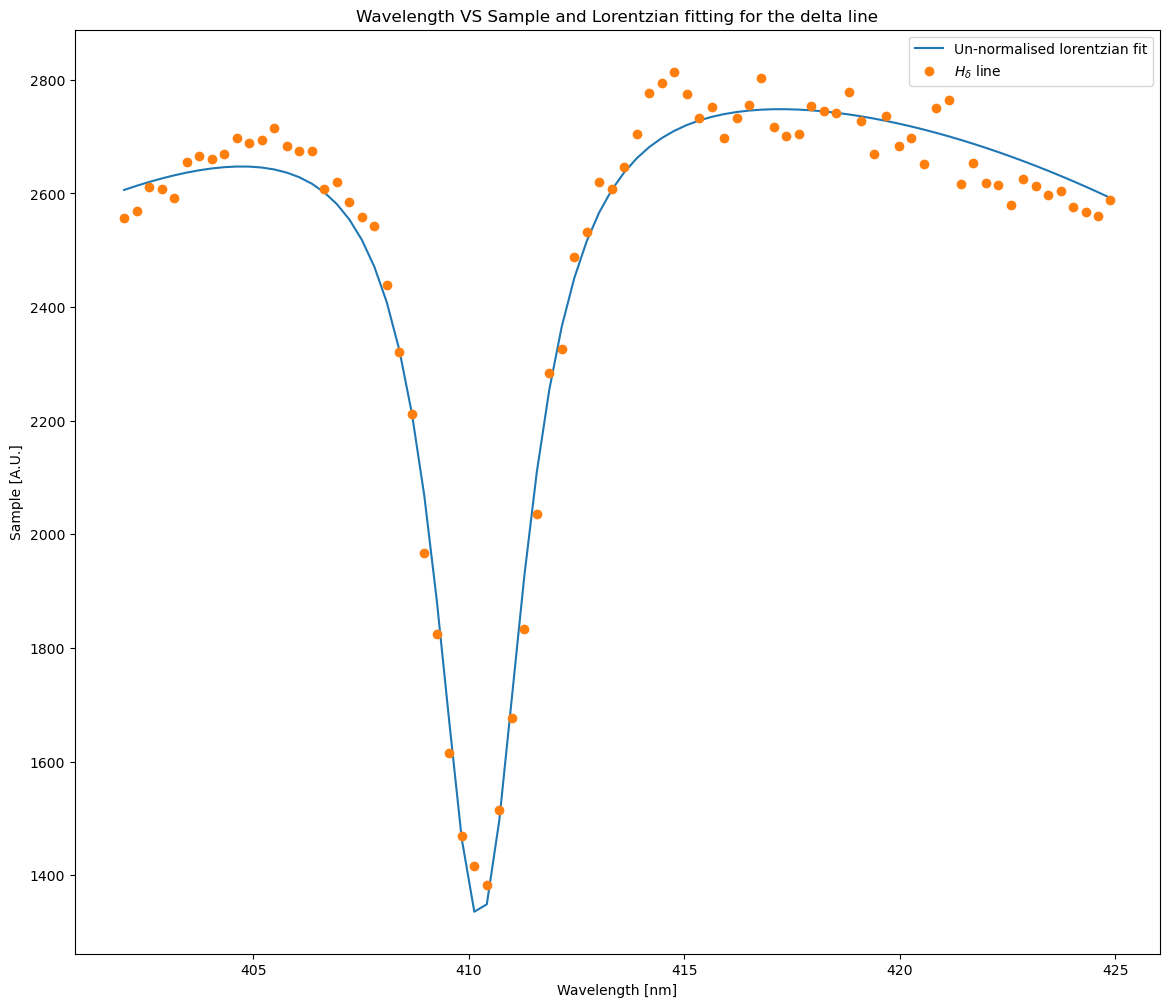

In [119]:
#convert to un-normalised data points
polyn = (a_delta_cont * wavelength[wavelength_range] **2) + b_delta_cont*wavelength[wavelength_range]  + c_delta_cont
l = lorentzian_function(wavelength[wavelength_range],line_par[0],line_par[1],line_par[2],line_par[3] )
overplot = l * polyn

#plot
plt.plot(wavelength[wavelength_range], overplot, label = "Un-normalised lorentzian fit" )
plt.plot(wavelength[wavelength_range], sample[wavelength_range], 'o', label = "$H_{\delta}$ line" )
plt.title('Wavelength VS Sample and Lorentzian fitting for the delta line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

Before we can compute the residuals, let us estimate and error on the sample. Since the data did not come with corresponding errors, we have to investigate what could be a possible source of noise in our data and its magnitude. We do this by looking at the tail (very end) of the spectrum since it contains no spectral lines. We take the standard deviation of these data points and consider it the noise in our data.

In [122]:
#Finding y_err through noise on tail 

wavelength_rg = np.where (wavelength > 800)
ystd = np.std(sample[wavelength_rg])
print (ystd)

48.83555727542956


We now proceed to compute the residuals and plot a graph of normalised residuals:
$$
residual_{\delta} = y_{\delta} - y_{lorentzian}
$$

$$
\text{normalised residuals} = \frac{residual_{\delta}}{\Delta y_{\delta}}
$$

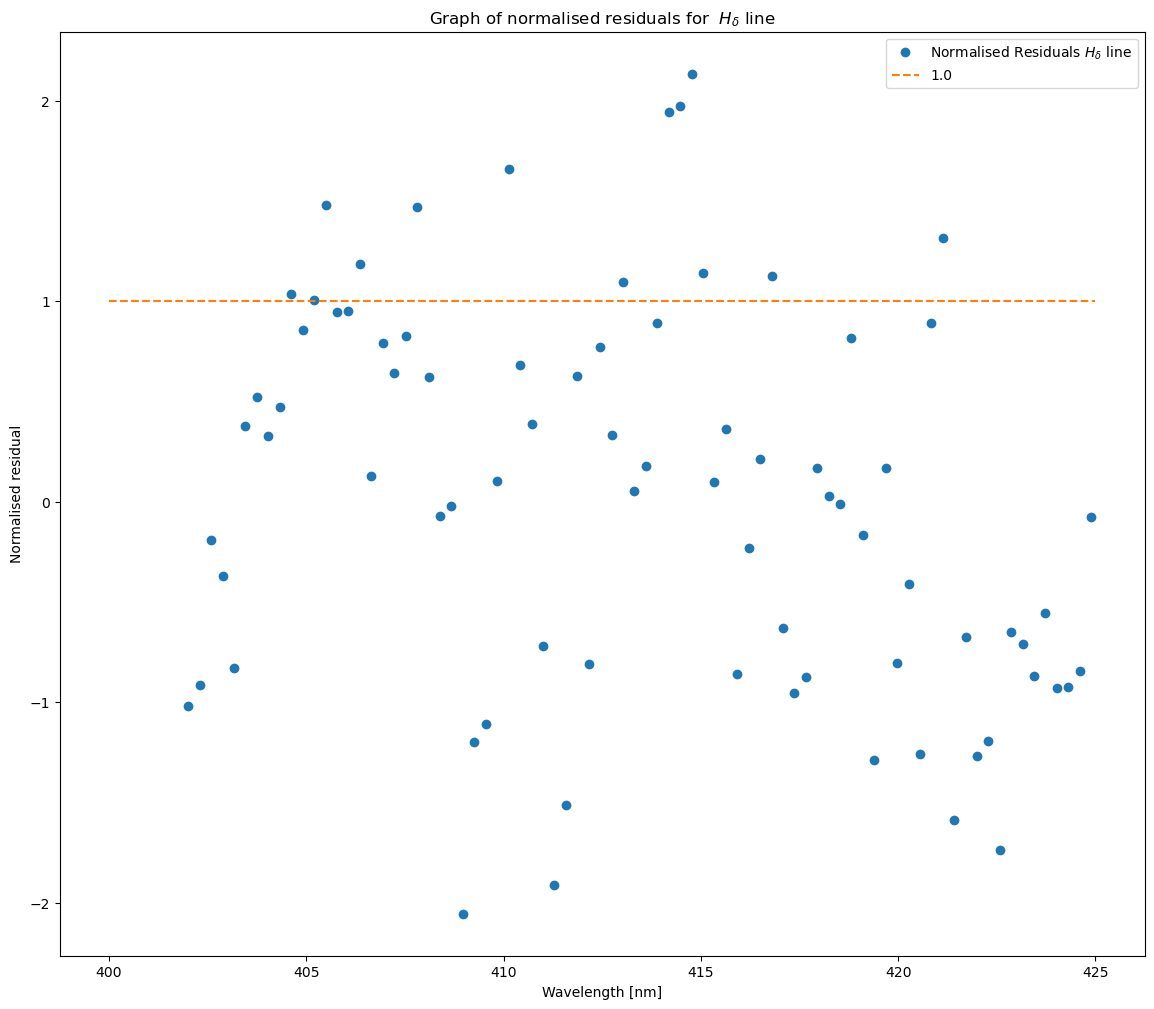

In [125]:
#finding residuals
residuals_delta = sample[wavelength_range] - overplot

#finding normalised residuals
normalisedres_delta = residuals_delta / ystd
normalisedres_delta

#plotting graph of residuals 
plt.plot(wavelength[wavelength_range],normalisedres_delta, 'o', label = "Normalised Residuals $H_{\delta}$ line" );
plt.plot((400,425), (1,1), "--" , label = '1.0')
plt.title("Graph of normalised residuals for  $H_{\delta}$ line")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Normalised residual")
plt.legend()


We see that our normalised residuals do not necessarily reside in the range of -1 to 1 however they are all in the range of -2 to 2. Our residuals are not symmetric, however this can be justified by the presence of the spectral line which explains why more normalised residuals reside in the negative rather than the positive. 

Creating a function for the reduced $\chi ^2$, and using it to calculate the value for the delta line:

In [129]:
#reduced chi squared function
def reduced_chisq (y, y_fit, y_err, num_parm):
    residuals = y - y_fit 
    chisq = np.sum((residuals/y_err)**2)
    k = len(y) - num_parm
    return chisq/k

In [131]:
red_chi_sq_delta = reduced_chisq (sample[wavelength_range], overplot, ystd, 4)
print (f"The Chi squared reduced for the lorentzian fit for the delta line is {red_chi_sq_delta}")

The Chi squared reduced for the lorentzian fit for the delta line is 0.9883629896560489


According to the Data Analysis and Statistics Booklet [1] a good fit is when we have a reduced $\chi ^2$ value close to 1. For the delta line, we get a value very close to 1, which evalutes the Lorentzian fit for the delta line as a suitable fit. We will expand on this more in the conclusion. 

### Lorentzian for $H_\gamma$

We now repeat the exact same procedure for the  $H_\gamma$ line. Please note that we will be resuing functions from before, as there will be no need in redefining them. 

Similar to the previous line, we have to estimate of coeffs of the lorentzian ($l_0$, $l_1$, $l_2$ and $l_3$). See our estimates and a brief justification for each:

- $l_0$ = 1 => offset level, value provided in guidance cell above
- $l_1$ =  - 0.55 => amplitude of the spectral line can be deduced from normalised plot of $H_\gamma$ 
- $l_2$ = 434.137 => calculated value of wavelength of  $H_\gamma$  using polyfit
- $l_3$ = 1 => width of normalised spectral line at its half maximum

In [136]:
### STUDENT COMPLETED CELL ###

# Modify the command line below to use the function you've defined above to fit your data.
# The outputs are the parameters of the fit and the covariance matrix (similar to polyfit).
# In the parenthesis you have in order: 
# AAA)The name of the function used by you in the definition above
# BBB & CCC)The portion of x axis to fit and the portion of y axis to fit.
# pp) A first approximate guess to the parameters used (CHANGE THESE!)

#using our function and estimated values for the fit coefficients
line_par_gamma , line_cov_gamma = optimize.curve_fit(lorentzian_function, wavelength[wavelength_range_gamma], y_normalized_gamma , p0=[1.0,-0.55,vertex_gamma,1])
print(f"The coeffs of the lorentzian fit for the delta line are l0 = {line_par_gamma[0]:.3f}, l1 = {line_par_gamma[1]:.3f}, l2 = {line_par_gamma[2]:.3f}, l3 = {line_par_gamma[3]:.3f}")
 
line_shape_gamma = lorentzian_function(wavelength[wavelength_range_gamma],line_par_gamma[0],line_par_gamma[1],line_par_gamma[2],line_par_gamma[3])


The coeffs of the lorentzian fit for the delta line are l0 = 1.031, l1 = -0.497, l2 = 434.115, l3 = 1.152


Upon inspection of these values, we see our estimates were appropriate. Nevertheless we will progress the task with the comupted coefficients as they are computed by the fit rather than estimated. Below we plot the the lorentzian over the normalised data points of the spectral line $H_\gamma$.

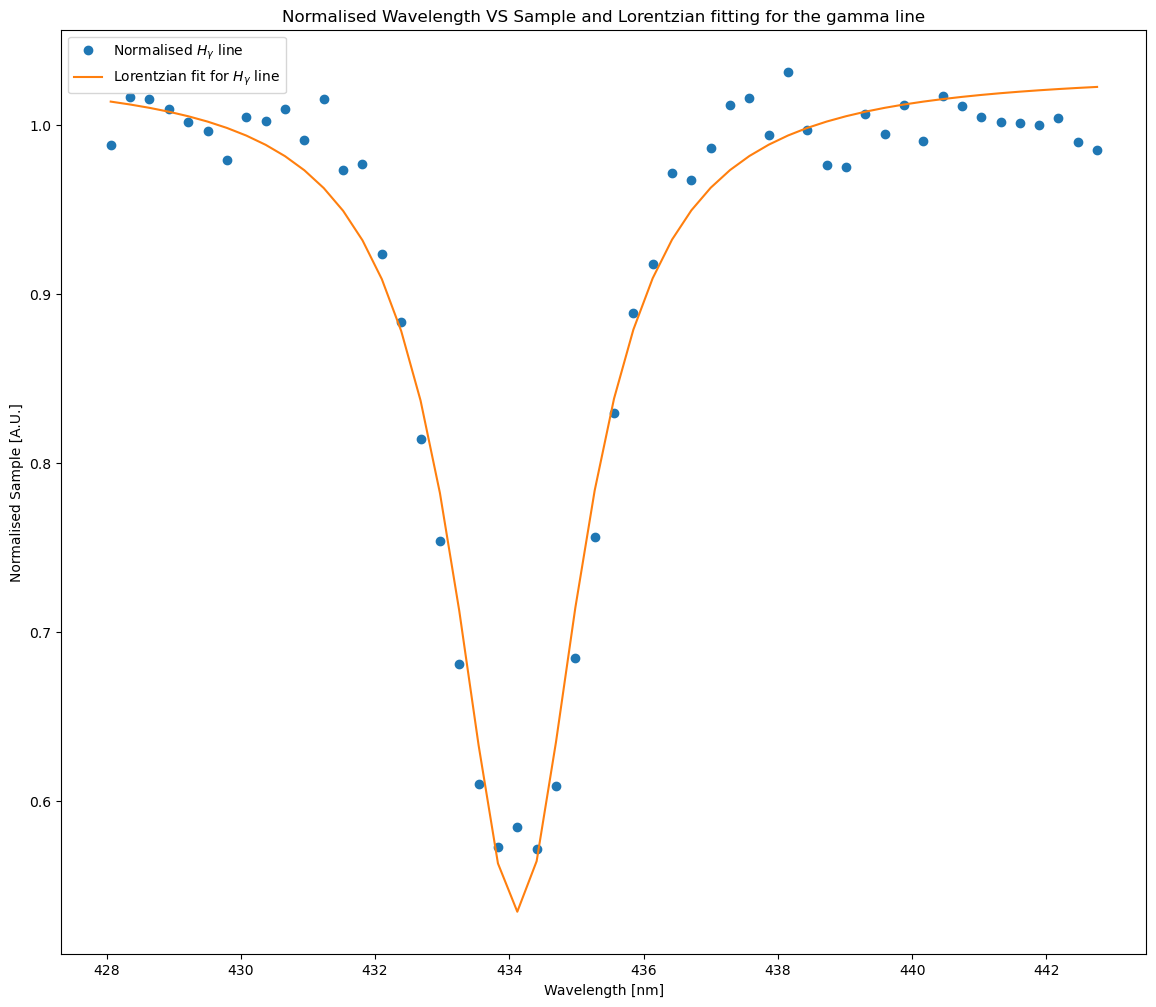

In [139]:
#plotting the lorentzian over the spectral line

plt.plot(wavelength[wavelength_range_gamma], y_normalized_gamma, 'o', label = "Normalised $H_{\gamma}$ line")
plt.plot (wavelength[wavelength_range_gamma], line_shape_gamma, label = 'Lorentzian fit for $H_{\gamma}$ line ' )
plt.title('Normalised Wavelength VS Sample and Lorentzian fitting for the gamma line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Normalised Sample [A.U.]')
plt.legend()

In [141]:
# Print the parameters and the relevant uncertainties.
l0_err_g, l1_err_g, l2_err_g, l3_err_g = np.sqrt(np.diag(line_cov_gamma)) 
print (f"The value for l_0 the gamma line as found by the lorentzian is {line_par_gamma[0]:.3f} ± {l0_err_g:.3f}")
print (f"The value for l_1 the gamma line as found by the lorentzian is {line_par_gamma[1]:.3f} ± {l1_err_g:.3f}")
print (f"The value for l_2 the gamma line as found by the lorentzian is {line_par_gamma[2]:.3f} ± {l2_err_g:.3f}")
print (f"The value for l_3 the gamma line as found by the lorentzian is {line_par_gamma[3]:.3f} ± {l3_err_g:.3f}")


The value for l_0 the gamma line as found by the lorentzian is 1.031 ± 0.006
The value for l_1 the gamma line as found by the lorentzian is -0.497 ± 0.014
The value for l_2 the gamma line as found by the lorentzian is 434.115 ± 0.032
The value for l_3 the gamma line as found by the lorentzian is 1.152 ± 0.060


As mentioned, the results show that our reasoning for the estimate of these parameters was reasonable, showing our comprehension of the Lorentzian fit for spectral lines. The most notable result is the one for $l_2 =  434.115 ± 0.032 nm$ as this represents the precise wavelength of the line. The value we obtained for  $H_{\gamma}$ line when performing the polynomial fit and finding the vertex was  434.137 ±  2.422 nm. While the value is exactly the same, we see that performing a Lorentzian fit yields an error which is about fifty times smaller. This concludes that this fitting method is much more reliable than the previous one.

Since our Lorentzian was applied to the normalised data set, we now have to convert it to the original data set in order to be able to compute residuals.

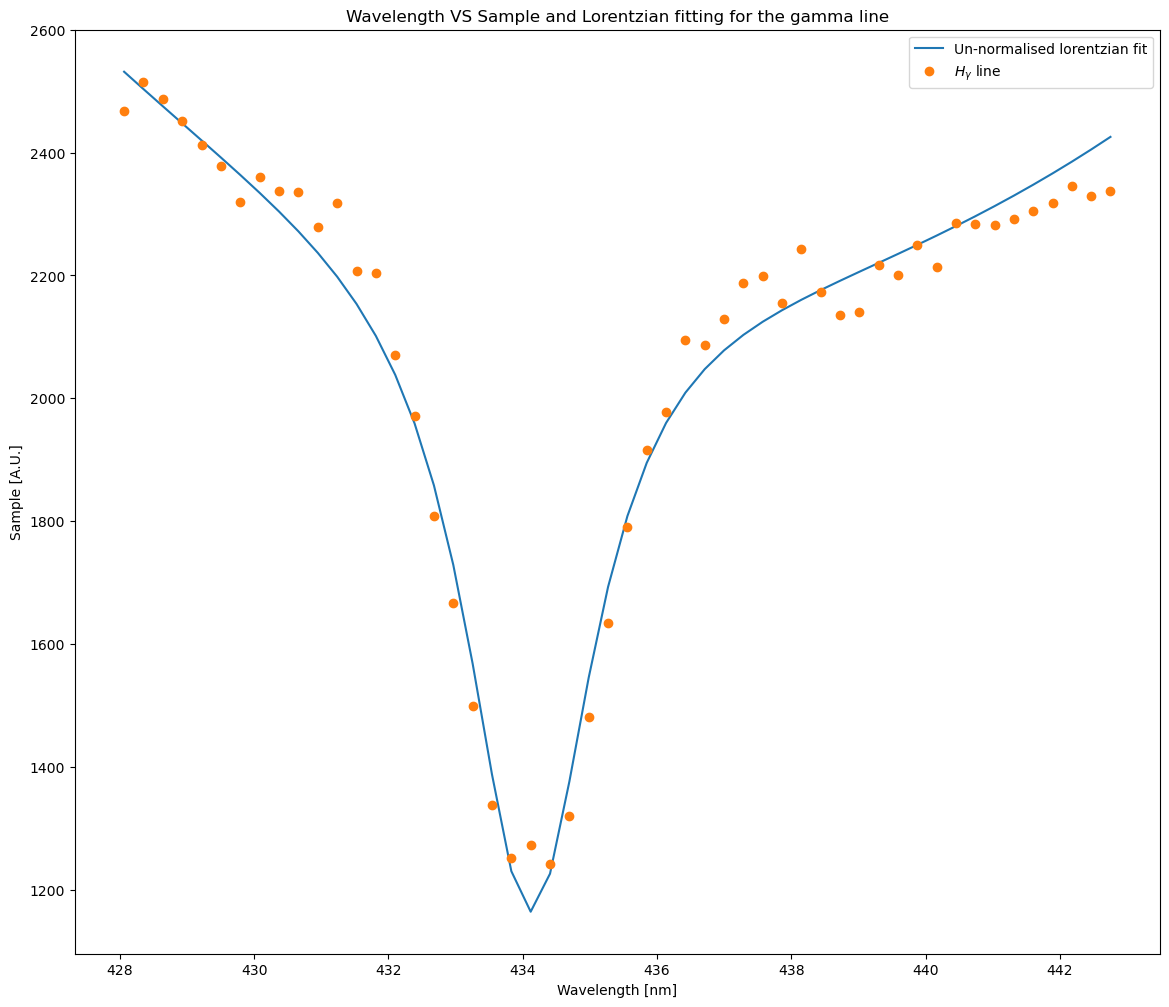

In [145]:
#convert to un-normalised data points for gamma
polyn_gamma = (a_gamma_cont * wavelength[wavelength_range_gamma] **2) + b_gamma_cont*wavelength[wavelength_range_gamma]  + c_gamma_cont
l_gamma = lorentzian_function(wavelength[wavelength_range_gamma],line_par_gamma[0],line_par_gamma[1],line_par_gamma[2],line_par_gamma[3] )
overplot_gamma = l_gamma * polyn_gamma

#plot
plt.plot(wavelength[wavelength_range_gamma], overplot_gamma, label = "Un-normalised lorentzian fit" )
plt.plot(wavelength[wavelength_range_gamma], sample[wavelength_range_gamma], 'o', label = "$H_{\gamma}$ line" )
plt.title('Wavelength VS Sample and Lorentzian fitting for the gamma line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

The errors computed for the $H_\delta$ line will be the same for $H_\gamma$, so we will just use the previous value. Let us now compute the residual, normalised residuals and $\chi ^2$ reduced.

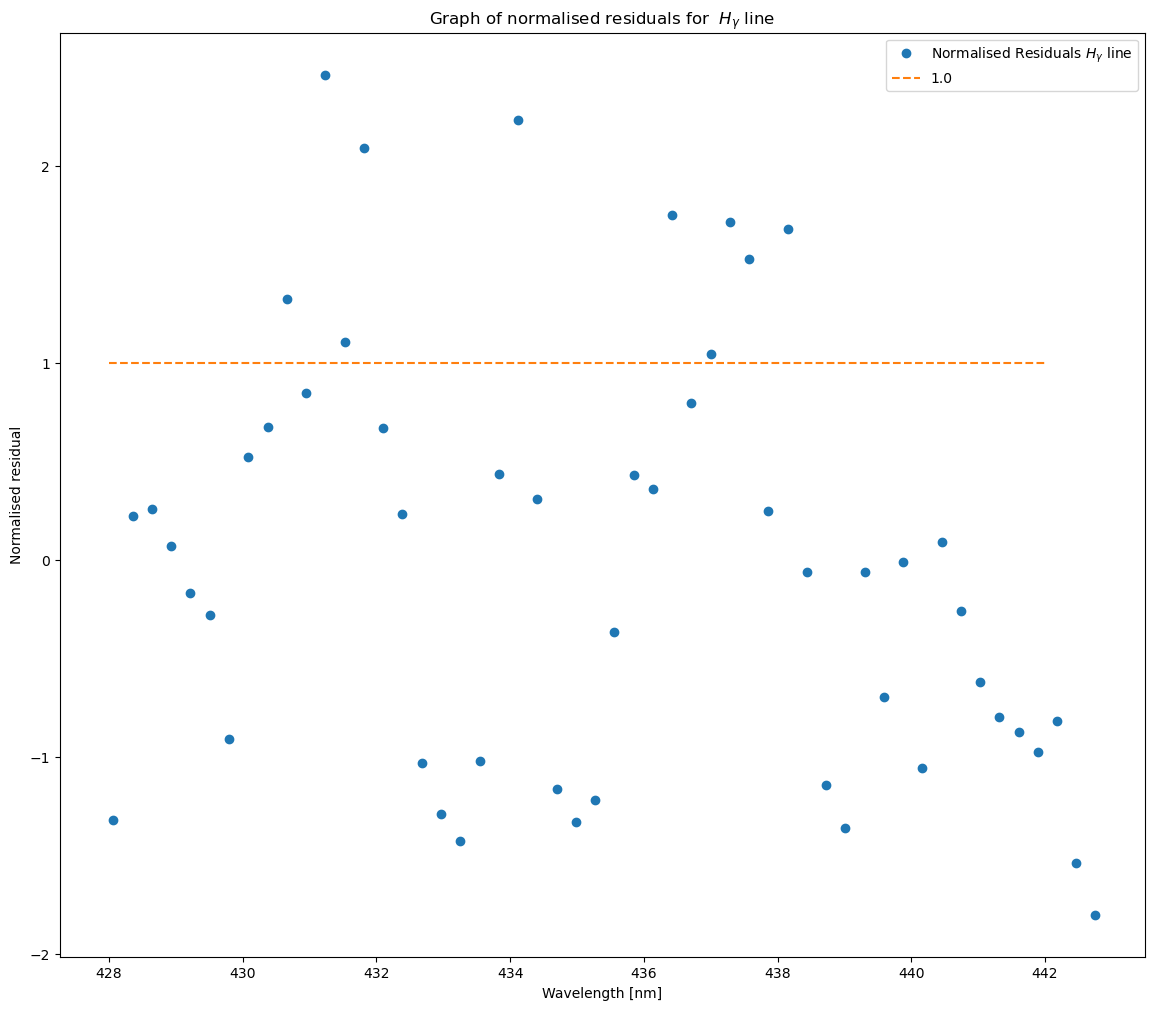

In [148]:
#finding residuals
residuals_gamma = sample[wavelength_range_gamma] - overplot_gamma

#finding normalised residuals
normalisedres_gamma = residuals_gamma / ystd
normalisedres_gamma

#plotting graph of residuals 
plt.plot(wavelength[wavelength_range_gamma],normalisedres_gamma, 'o', label = "Normalised Residuals $H_{\gamma}$ line" );
plt.plot((428,442), (1,1), "--" , label = '1.0')
plt.title("Graph of normalised residuals for  $H_{\gamma}$ line")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Normalised residual")
plt.legend()


We see that our normalised residuals do not necessarily reside in the range of -1 to 1 however they are all in the range of -2 to 2. Our residuals are not symmetric, however this can be justified by the presence of the spectral line which explains why more normalised residuals reside in the negative rather than the positive. We see that the normalised residuals for the  $H_{\gamma}$ and  $H_{\delta}$ have a similar distribution, which makes sense since the shape of the spectral line is similar in both cases.

Creating a function for the reduced $\chi ^2$, and using it to calculate the value for the gamma line:

In [152]:
#chi sq reduced for gamma
red_chi_sq_gamma = reduced_chisq (sample[wavelength_range_gamma], overplot_gamma, ystd, 4)
print (f"The Chi squared reduced for the lorentzian fit for the gamma line is {red_chi_sq_gamma}")

The Chi squared reduced for the lorentzian fit for the gamma line is 1.2725442232156043


For the gamma line, we get a $\chi ^2$ reduced value very close to 1, which evalutes the Lorentzian fit for the gamma line as a suitable fit. It is worth to note that while for the $H_\delta$ line the  $\chi ^2$ reduced was slightly less than one, for $H_\gamma$ line it is more than one. We will expand on this more in the conclusion.

## Lorentzian for $H_\gamma$

## Part C : Pair of lines

<div class='alert alert-success'> 
If you did this on H delta now do it on H gamma or viceversa.

<ul>
<li> Once you perform the same set of operations above for the second line, compare the differences between the rest-frame wavelengths and those obtained here (or similarly compare the doppler shift velocities). </li>
<li> Comment on your results in a Markdown cell arguing the physics of what you observe.</li>    
</ul>
</div>

Let us restate our results:

In [159]:
# wavelength from lorentzian fit 
print (f"The H delta wavelength as obtained from the Lorentzian is {line_par[2]:.3f} ± {l2_err:.3f}")
print (f"The H gamma wavelength as obtained from the Lorentzian is  {line_par_gamma[2]:.3f} ± {l2_err_g:.3f}")

The H delta wavelength as obtained from the Lorentzian is 410.250 ± 0.023
The H gamma wavelength as obtained from the Lorentzian is  434.115 ± 0.032


In [161]:
#offset from the theoretical rest wavelength 
offset_d = line_par[2] - 410.174
offset_g = line_par_gamma[2] - 434.0472

print (f"The offset for the H delta from the rest wavelength {offset_d}")
print (f"The offset for the H gamma from the rest wavelength {offset_g}")

The offset for the H delta from the rest wavelength 0.07624473576493074
The offset for the H gamma from the rest wavelength 0.06764427832746378


Which is approximately 2-3 times the corresponding error. Lets now compute the velocity.

The operations for both spectral lines have been computed in parallel in parts A and B. We will now compute the velocities from the Lorentzian fits and compare them to those we got from the quadratic fits. 

Using the same method as before:

$$
v_{\gamma} = \frac{c \Delta \lambda_{\gamma}}{\lambda_0} 
$$

Where:
- c = speed of light
- $\Delta \lambda_{\gamma}$ = difference in rest and the computed vertex wavelength by the lorentzian
- $\lambda_0$ = rest wavelength

Where we use the rest wavelength values:
- $\lambda_{0g}$ rest = 434.0472 nm (as stated above)
- $\lambda_{0d}$ rest = 410.174 nm [2]

The error for $\Delta v_{\gamma}$ is propagated and added in quadrature to give:
$$
\Delta v_{\gamma} = \frac{c}{\lambda_{0g}} * \Delta \lambda_{\gamma}
$$

We then apply both formulas to delta.

In [165]:
### STUDENT COMPLETED CELL ###

# Doppler shift calculation for rest wavelength of Hgamma
c = 3*10**8
rest_hgamma = 434.0472
gamma_line_l = line_par_gamma[2]
star_speed_gamma_l= (((c *(gamma_line_l - rest_hgamma))/(rest_hgamma)) / 1000)

#error on h-gamma
err_star_speed_gamma_l = (((c/rest_hgamma) * l2_err_g) /1000)


# Doppler shift calculation for rest wavelength of H delta
c = 3*10**8
rest_hdelta = 410.174
delta_line_l = line_par[2]
star_speed_delta_l = (((c *(delta_line_l - rest_hdelta))/(rest_hdelta)) / 1000)

#error
err_star_speed_delta_l = (((c/rest_hdelta) * l2_err) /1000)

print (f"The speed of the star from the H gamma line is: {star_speed_gamma_l:.3f} ± {err_star_speed_gamma_l:.3f} km/s")
print (f"The speed of the star from the H delta line is: {star_speed_delta_l:.3f} ± {err_star_speed_delta_l:.3f} km/s")
 

The speed of the star from the H gamma line is: 46.754 ± 22.286 km/s
The speed of the star from the H delta line is: 55.765 ± 16.575 km/s


In [167]:
#quadratic fit
print ("For the quadratic fit:")
print (f"The speed of the star from the H gamma line is: {star_speed_gamma:.3f} ± {err_star_speed_gamma:.3f} km/s")
print (f"The speed of the star from the H delta line is: {star_speed_delta:.3f} ± {err_star_speed_delta:.3f} km/s")

#lorentzian
print ("For the Lorentzian fit:")
print (f"The speed of the star from the H gamma line is: {star_speed_gamma_l:.3f} ± {err_star_speed_gamma_l:.3f} km/s")
print (f"The speed of the star from the H delta line is: {star_speed_delta_l:.3f} ± {err_star_speed_delta_l:.3f} km/s")
 

For the quadratic fit:
The speed of the star from the H gamma line is: 62.264 ± 1674.010 km/s
The speed of the star from the H delta line is: 55.636 ± 924.667 km/s
For the Lorentzian fit:
The speed of the star from the H gamma line is: 46.754 ± 22.286 km/s
The speed of the star from the H delta line is: 55.765 ± 16.575 km/s


Having obtained the results stated above for the two methods of fitting, we reach a surprising conclusion. While speed from the H gamma lines changes by more than 20km/s , the H Delta line barely does. This implies that while for the H gamma line the quadratic fit appeared to match the Lorentzain quite well, and yield similar values in recession speeds, the H Delta line models are mismatched. As we are expecting a value around 55 km/s, we could imply that taking the mean of the two velocities through different methods would yield this result. Additionally, our errors get significantly reduced through using the Lorentzian fit, nevertheless they're still quite large. This seems to suggest that we might be overlooking certain factors that might contribute to errors. 

## Conclusion:


To summarize, in this task we investigated the spectrum of Vega and looked at two spectral line $H_\delta$ and $H_\gamma$. 

We firstly looked at each line and tried to plot a quadratic fit to each spectral line. This was doen by using np.where() to select a subset of data containing the spectral line and them we used a second degree polyfit to fit a quadratic fit. From the obtained equation of the quadratic fit, we then computed the vertex which corresponds to the wavelength of the spectral line. While for both lines we obtained a result that coincided with the theoretical value within the errors. Nevertheless the errors were a couple of nanometers, inferring we could obtain a better model.

We then proceeded to investigate the continuum of each spectral line. This meant we removed the spectral line itself and only looked at the "wings" of the spectral line to which we also fitted a second degree polyfit. We proceeded to normalise the data so that the wings have a value of around 1.0. This was mostly sucessful, as on our plots we see that the data points of the wings do indeed mostly coincide with a normalised value. 

Using our normalised models we were then able to estimate values for a Lorentzian fit for each spectral line. After computing the proper coefficients for each spectral line we saw that our estimates from the normalised models were roughly correct. We then fited a Lorentzian model to both of our spectral lines. The values of wavelength we obtained were similar to those we did with the quadratic fit, but the errros reduced significantly showing that fitting by the Lorentzian does yield more reliable data. We evaluated the goodness of these fits by computing the residuals and plotting the normalised residuals. We saw that these did not reside in the expected range of -1 to 1, but instead -2 to 2. Additionally, the normalised residuals were not perfectly symmetrical as we encountred more data points in the negative rather than positive. This logically makes sense becasue of the dip in the spectrum that is represented by the spectral line. These results of the normalised residuals also infer that our error estimation through taking a portion of a spectrum and looking for its noise uisng standrad deviation was good, but perhaps not accurate enough when applied to the regions of spectral lines. We conclude that a better distribution of normalised residuals would be obtained if we had a more accurate method for estimating noise of the data or just an error in measurement of the instrument. 

Subsequently, we computed the $\chi ^ 2$ reduced as an evaluation for the goodness of the fit. For the $H_\delta$ line we obtained a value very close to 1.0, implying that the Lorentzian fit the $H_\delta$ line very well. For the $H_\gamma$ line, we got a value slightly larger than 1.0 which implies that the fit was slightly less suitable than the one we obatined for the $H_\delta$ line.

Ultimately, we used the results for the wavelength of each spectral line from the Lorentzian fit to calculate the comparison to the rest wavelength and the speed of Vega. The speeds we obtained for Vega did not coincide with each other. While the H-delta line velocity is 55.765 ± 16.575 km/s the H gamma is 46.754 ± 22.286 km/s. This implies that our fits and results for H-delta are more accurate than for H gamma. This is also suggested by the size of the errors. This conclusion is also supported by the $\chi ^ 2$ reduced. This calls for a reevalution of this method and its validity when it comes to the  $H_\gamma$ line. In a further investigation, we could try fitting data to an outlier stripped data set for the $H_\gamma$ line or look at a spectrum that is an average of more spectra than just 10. Developing an algorithm for picking ranges of spectral lines based on quantifiable parameters might also improve the reliability and validity of our methods. 


## References:

[1] Llorente-Garcia I and Jones P. Data Analysis and Statistics Booklet, Practical Physics and Computing 1: Module PHAS0007. [online] UCL: London; 2022 [Accessed 29 January 2026]. Available from: https://moodle.ucl.ac.uk/course/view.php?id=46794&section=1.

[2] Atomic spectral database. [online] NIST [Acessed 29 January 2026]. Available from: https://www.nist.gov/pml/atomic-spectra-database